## Loading and cleaning data

In [1]:
import pandas as pd
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.ndimage


# Load data from zip file
zip_path = "data/dmc_122124.zip"
zip_path = "data/dmc_122724.zip"
zip_path = "data/dmc_010225.zip"
zip_path = "data/dmc_010625.zip"
records = []

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    for filename in zip_ref.namelist():
        if filename.endswith('.npy'):
            # Extract parameters from directory name (e.g. BRO_64_1_3e-4)
            if filename.startswith('__MACOSX'):
                continue
            env_name = filename.split('/')[2].split('.')[0]  # Get environment name from path
            name = filename.split('/')[1]
            params = name.split('_')
            batch_size = int(params[1])
            utd = int(params[2])
            learning_rate = float(params[3])
            # Load array data
            with zip_ref.open(filename) as f:
                arr = np.load(f)
                
            # Create record with metadata and results
            records.append({ 
                'env_name': env_name,
                'batch_size': batch_size,
                'utd': utd,
                'learning_rate': learning_rate,
                'training_step': arr[:, 0],
                'return': arr[:, 1:],
                'mean_return': np.mean(arr[:, 1:], axis=1),  # Add summary statistics
                # 'return': arr[:, 1:7],
                # 'mean_return': np.mean(arr[:, 1:7], axis=1),
                'std_return': np.std(arr[:, 1:7], axis=1) / np.sqrt(10)  # Standard Error of Mean over 10 seeds
            })

# Convert to pandas DataFrame
df = pd.DataFrame(records)

df['learning_rate'] = df['learning_rate'].replace(1.2e-2, 1.2e-3) # mislabeled in the data

# merge additional seeds for hopper-stand and reacher-easy
for env in ['hopper-stand', 'reacher-easy']:
    base_envs = df[df['env_name'] == env]
    seeds_envs = df[df['env_name'] == f'{env}_seeds']
    
    for i in range(len(base_envs)):
        base_env = base_envs.iloc[i]
        seeds_env = seeds_envs.iloc[i]
        
        # Combine returns arrays
        min_length = min(base_env['return'].shape[0], seeds_env['return'].shape[0])
        merged_returns = np.concatenate([base_env['return'][:min_length], seeds_env['return'][:min_length]], axis=1)
        merged_mean = np.mean(merged_returns, axis=1)
        merged_std = np.std(merged_returns, axis=1)
        training_steps = base_env['training_step'][:min_length]

        # Create new row with merged data
        merged_row = base_env.copy()
        merged_row.update({'env_name': f'{env}_merged', 'training_step': training_steps, 'return': merged_returns, 'mean_return': merged_mean, 'std_return': merged_std})
        df = df.append(merged_row, ignore_index=True)

# drop hopper-stand_seeds and reacher-easy_seeds as well as hopper-stand and reacher-easy
df = df[~df['env_name'].isin(['hopper-stand_seeds', 'reacher-easy_seeds', 'hopper-stand', 'reacher-easy'])]

# Add isotonic regression on return data
from sklearn.isotonic import IsotonicRegression
iso_reg_results = []

for _, row in df.iterrows():
    # Initialize isotonic regression model
    ir = IsotonicRegression(out_of_bounds='clip')
    
    # Fit on training steps and mean returns
    x = row['training_step']
    y = row['mean_return']
    # Bootstrap sampling from returns
    # Sample with replacement from the returns at each timestep
    # bootstrap_samples = np.random.choice(row['return'].shape[1], size=row['return'].shape[1], replace=True)
    # y = np.mean(row['return'][:, bootstrap_samples], axis=1)
    # print(row['mean_return'].shape, row['return'].shape)
    
    # Fit the model and get predictions
    ir.fit(x, y)
    y_iso = ir.predict(x)
    
    iso_reg_results.append(y_iso)

# Add isotonic regression results to dataframe    
df['return_isotonic'] = iso_reg_results

# Calculate crossings for each threshold and store in array
thresholds = [100, 200, 300, 400, 500, 600, 700, 800]

crossings_array = []

for _, row in df.iterrows():
    row_crossings = []
    
    for threshold in thresholds:
        # Get crossing from isotonic regression
        crossing_idx = np.where(row['return_isotonic'] > threshold)[0]
        row_crossings.append(row['training_step'][crossing_idx[0]] if len(crossing_idx) > 0 else np.nan)
    
    crossings_array.append(row_crossings)

df['crossings'] = crossings_array

# Remove hopper-stand_seeds and reacher-easy_seeds
# df = df[~df['env_name'].isin(['hopper-stand_seeds', 'reacher-easy_seeds'])]

# df

In [2]:
# add error bars via bootstrap

import os
import pickle

# Try to load cached results
cache_file = f'cache/bootstrap_results_{zip_path.split("/")[-1]}.pkl'
if os.path.exists(cache_file):
    with open(cache_file, 'rb') as f:
        results = pickle.load(f)
        iso_reg = results['iso_reg']
        iso_reg_stds = results['iso_reg_stds'] 
        crossings = results['crossings']
        crossings_std = results['crossings_std']
else:
    iso_reg = []
    iso_reg_stds = []
    crossings = []
    crossings_std = []
    for _, row in df.iterrows():    
        n_bootstrap = 100  # Number of bootstrap samples. 100 seems enough for std to converge
        ir = IsotonicRegression(out_of_bounds='clip')
        x = row['training_step']
        y_iso_samples = []
        sample_crossings = []
        for _ in range(n_bootstrap):
            # Sample with replacement
            sample_indices = np.random.randint(0, row['return'].shape[1], size=row['return'].shape[1])
            y = np.mean(row['return'][:, sample_indices], axis=1)  # Average the bootstrap samples
            
            # Fit isotonic regression on this bootstrap sample
            ir.fit(x, y)
            y_iso = ir.predict(x)
            y_iso_samples.append(y_iso)

            # For each bootstrap sample, find threshold crossings
            sample_crossing = []
            for threshold in thresholds:
                crossing_idx = np.where(y_iso > threshold)[0]
                crossing = row['training_step'][crossing_idx[0]] if len(crossing_idx) > 0 else np.nan
                sample_crossing.append(crossing)
            sample_crossings.append(sample_crossing)
        
        # Store mean prediction, crossing statistics, and isotonic std
        iso_reg.append(y_iso_samples)
        crossings.append(np.array(sample_crossings))
        crossings_std.append(np.nanstd(sample_crossings, axis=0))
        iso_reg_stds.append(np.std(y_iso_samples, axis=0))

    # Save results to cache
    results = {
        'iso_reg': iso_reg,
        'iso_reg_stds': iso_reg_stds,
        'crossings': crossings, 
        'crossings_std': crossings_std
    }
    with open(cache_file, 'wb') as f:
        pickle.dump(results, f)

df['return_isotonic_bootstrap'] = iso_reg
df['crossings_bootstrap'] = crossings
df['crossings_std'] = crossings_std
df['return_isotonic_std'] = iso_reg_stds

mean_std = np.nanmean(np.array(crossings_std))
print(f"Average standard deviation across all conditions: {mean_std:.2f}")


Average standard deviation across all conditions: 9949.59


/home/oleh/miniconda3/envs/rlgpu/lib/python3.7/site-packages/matplotlib/axes/_axes.py:1066: RuntimeWarning: All-NaN axis encountered
  minx = np.nanmin(masked_verts[..., 0])
/home/oleh/miniconda3/envs/rlgpu/lib/python3.7/site-packages/matplotlib/axes/_axes.py:1067: RuntimeWarning: All-NaN axis encountered
  maxx = np.nanmax(masked_verts[..., 0])


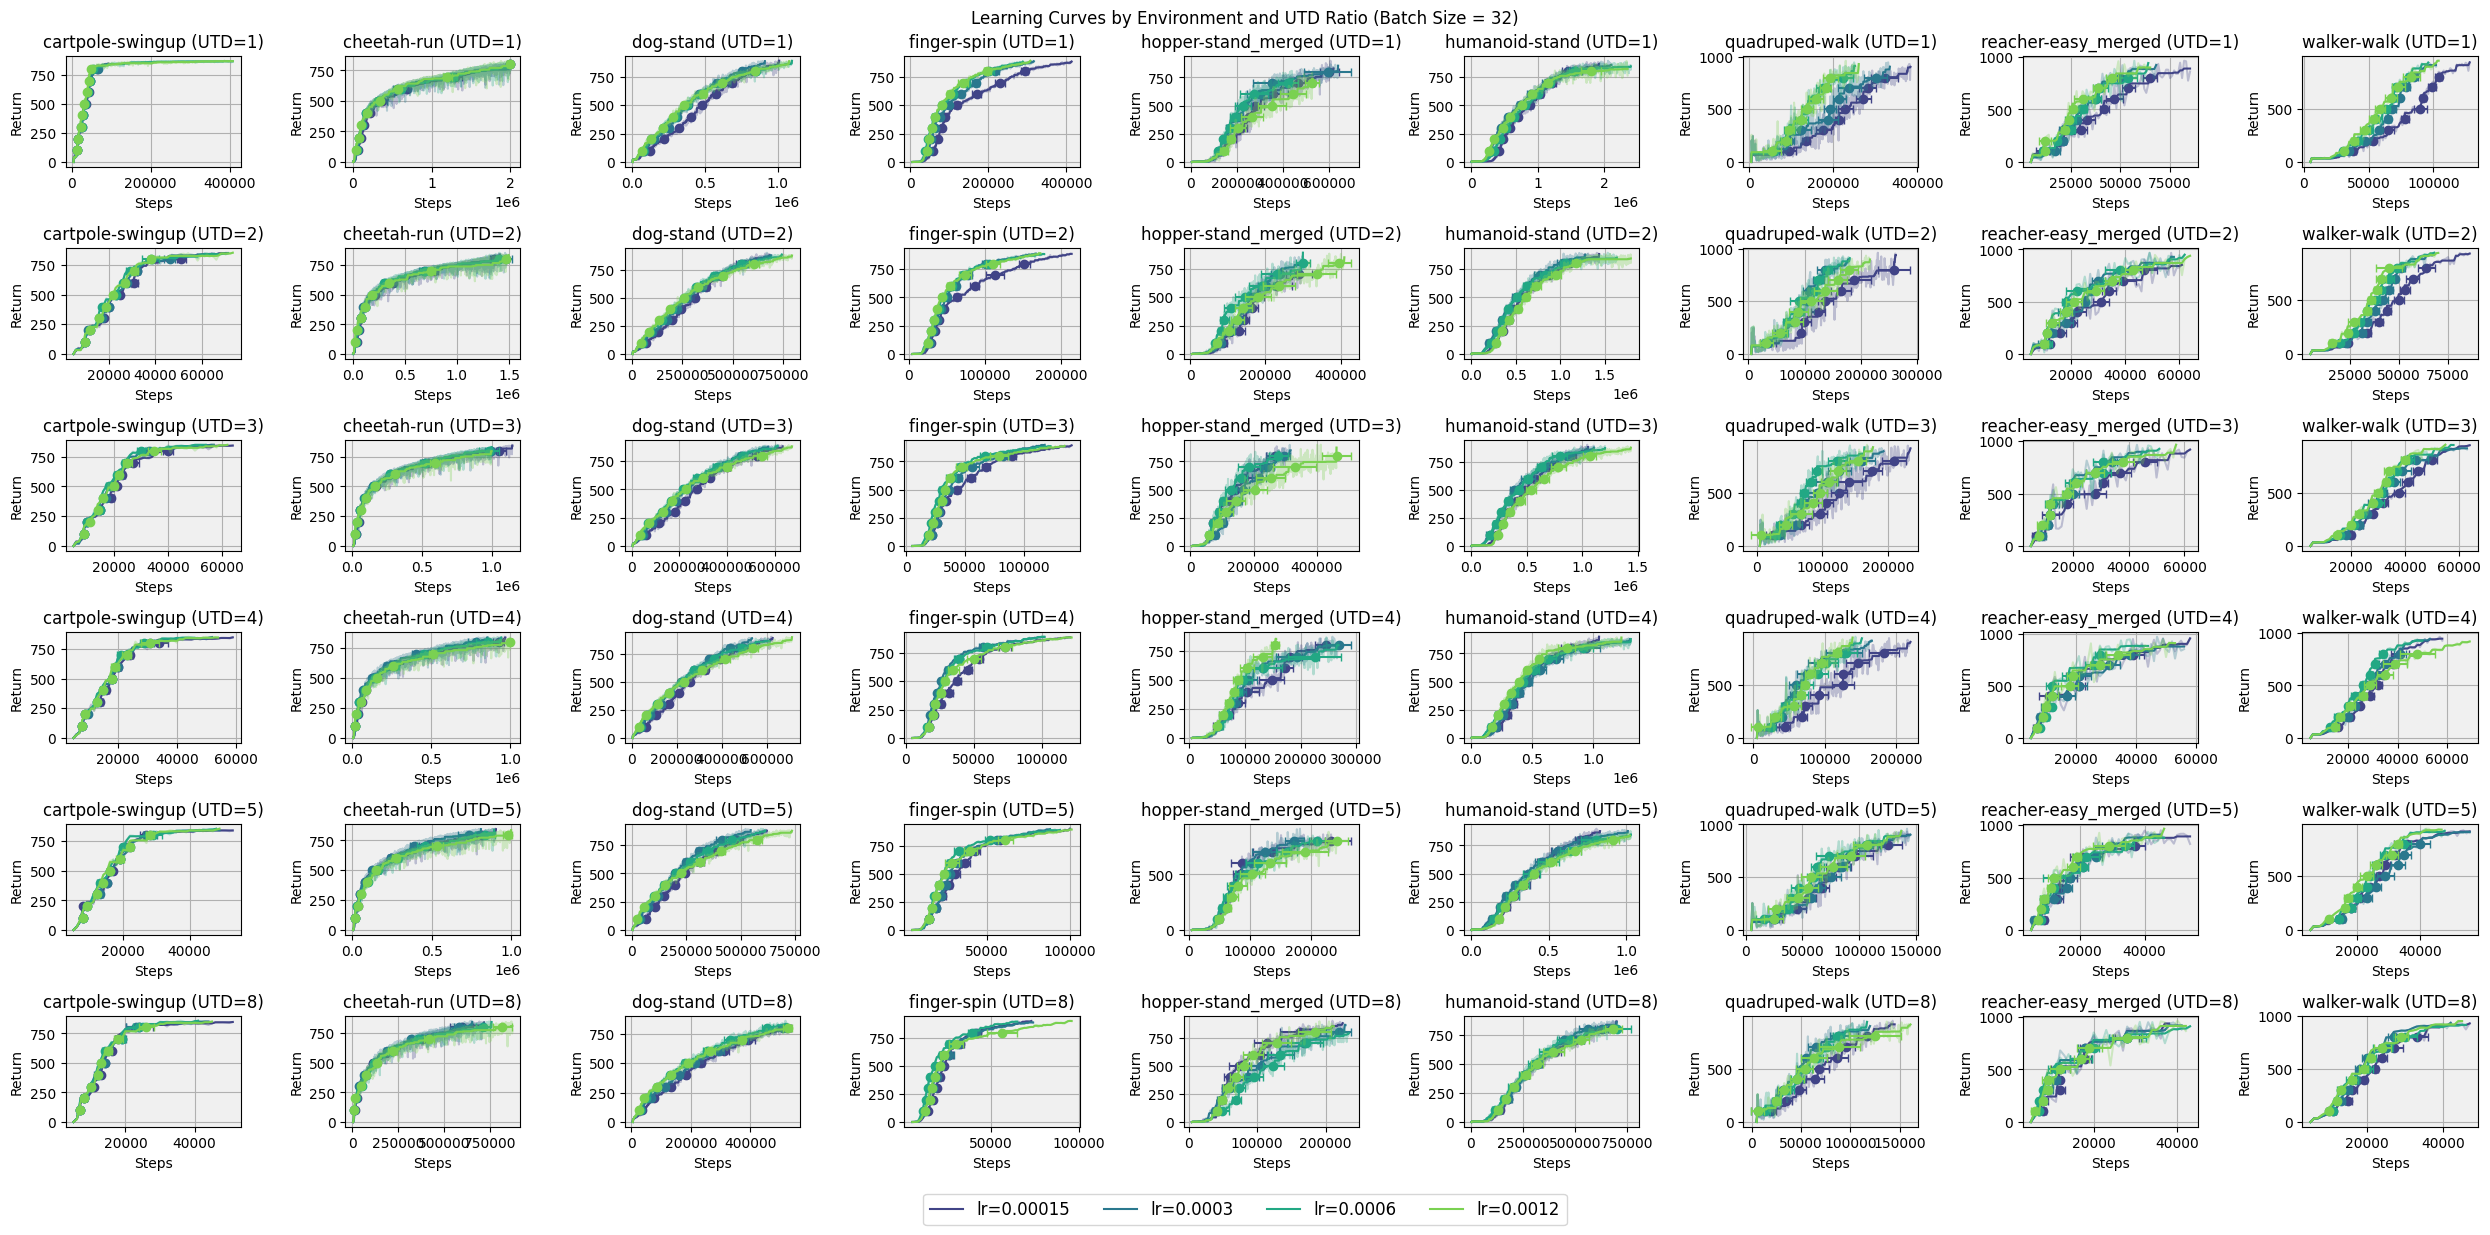

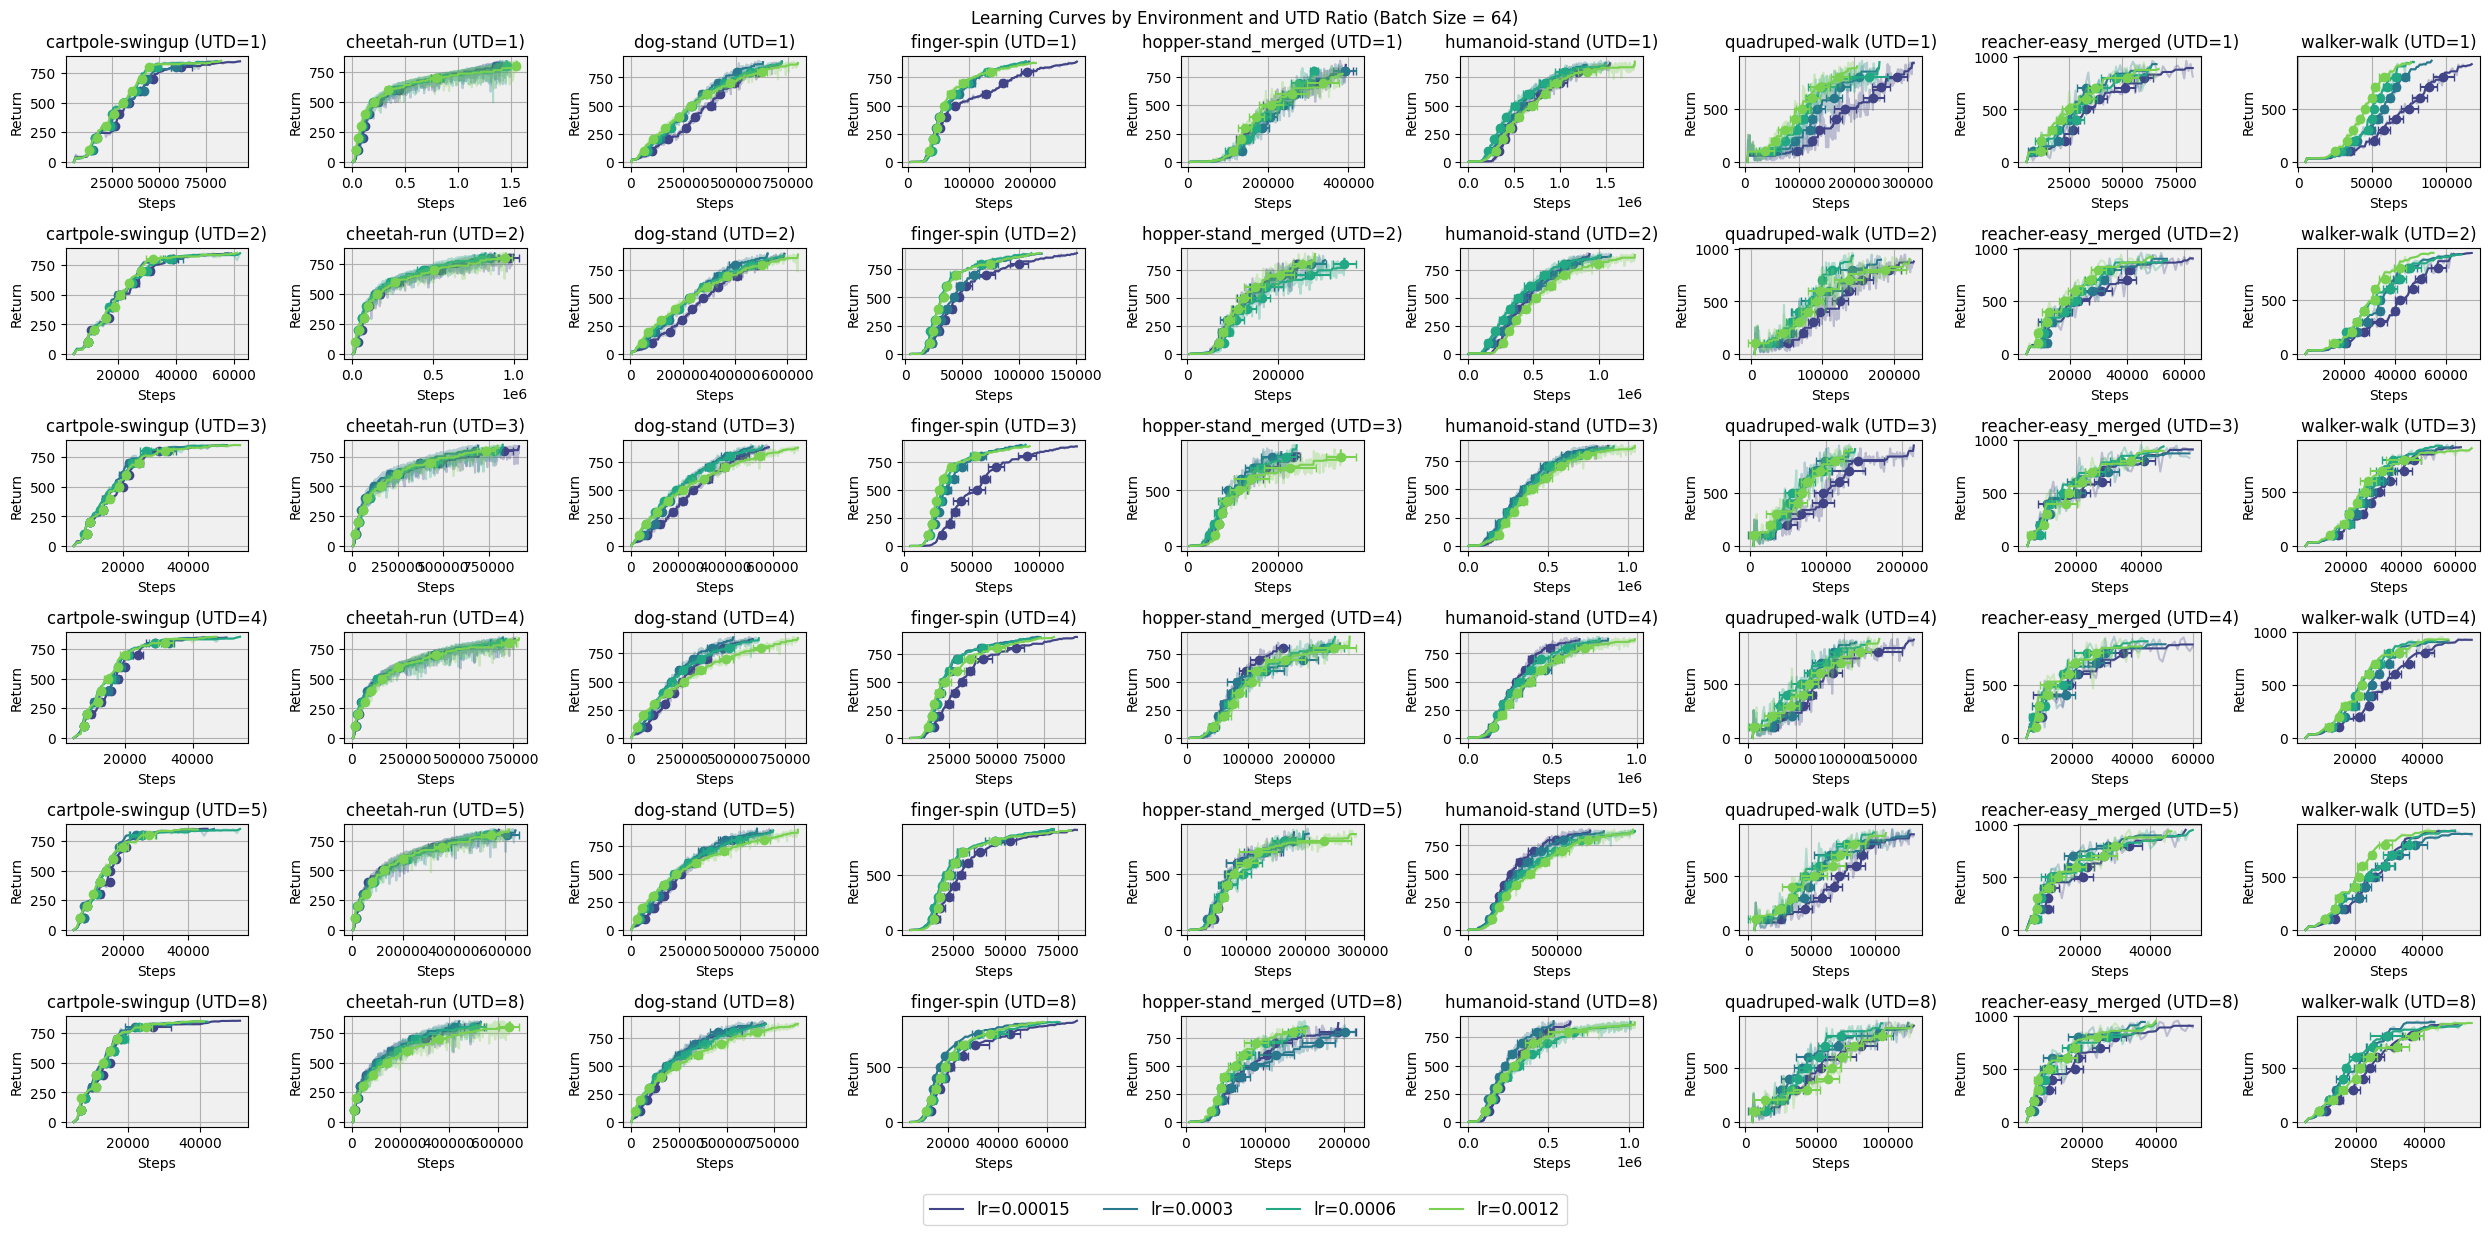

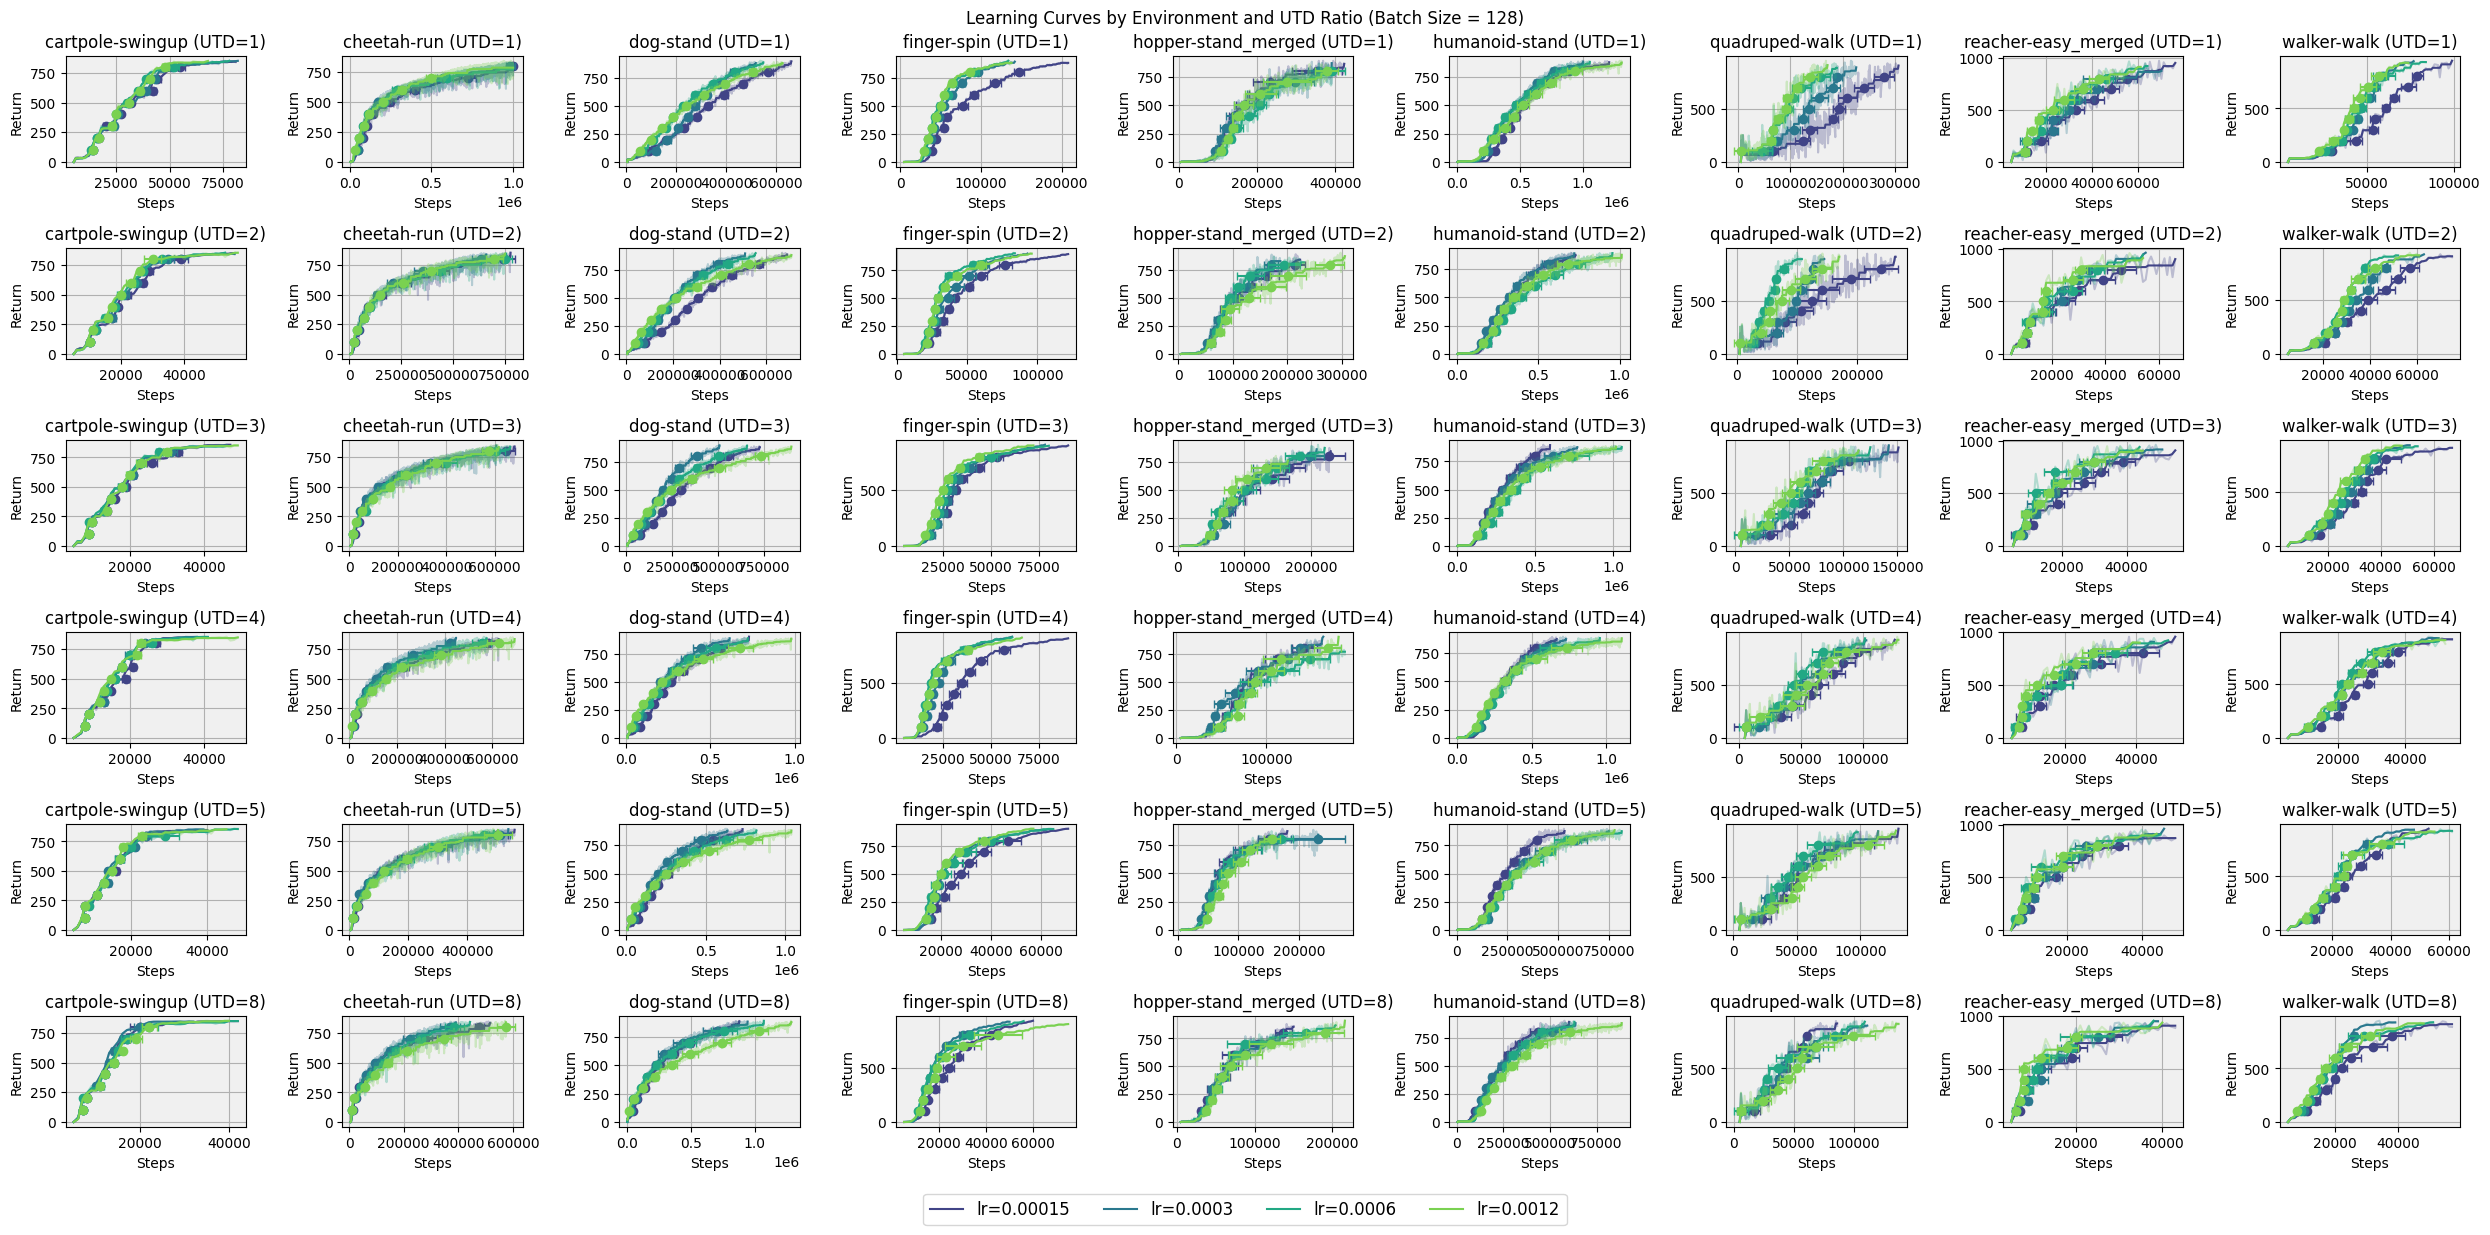

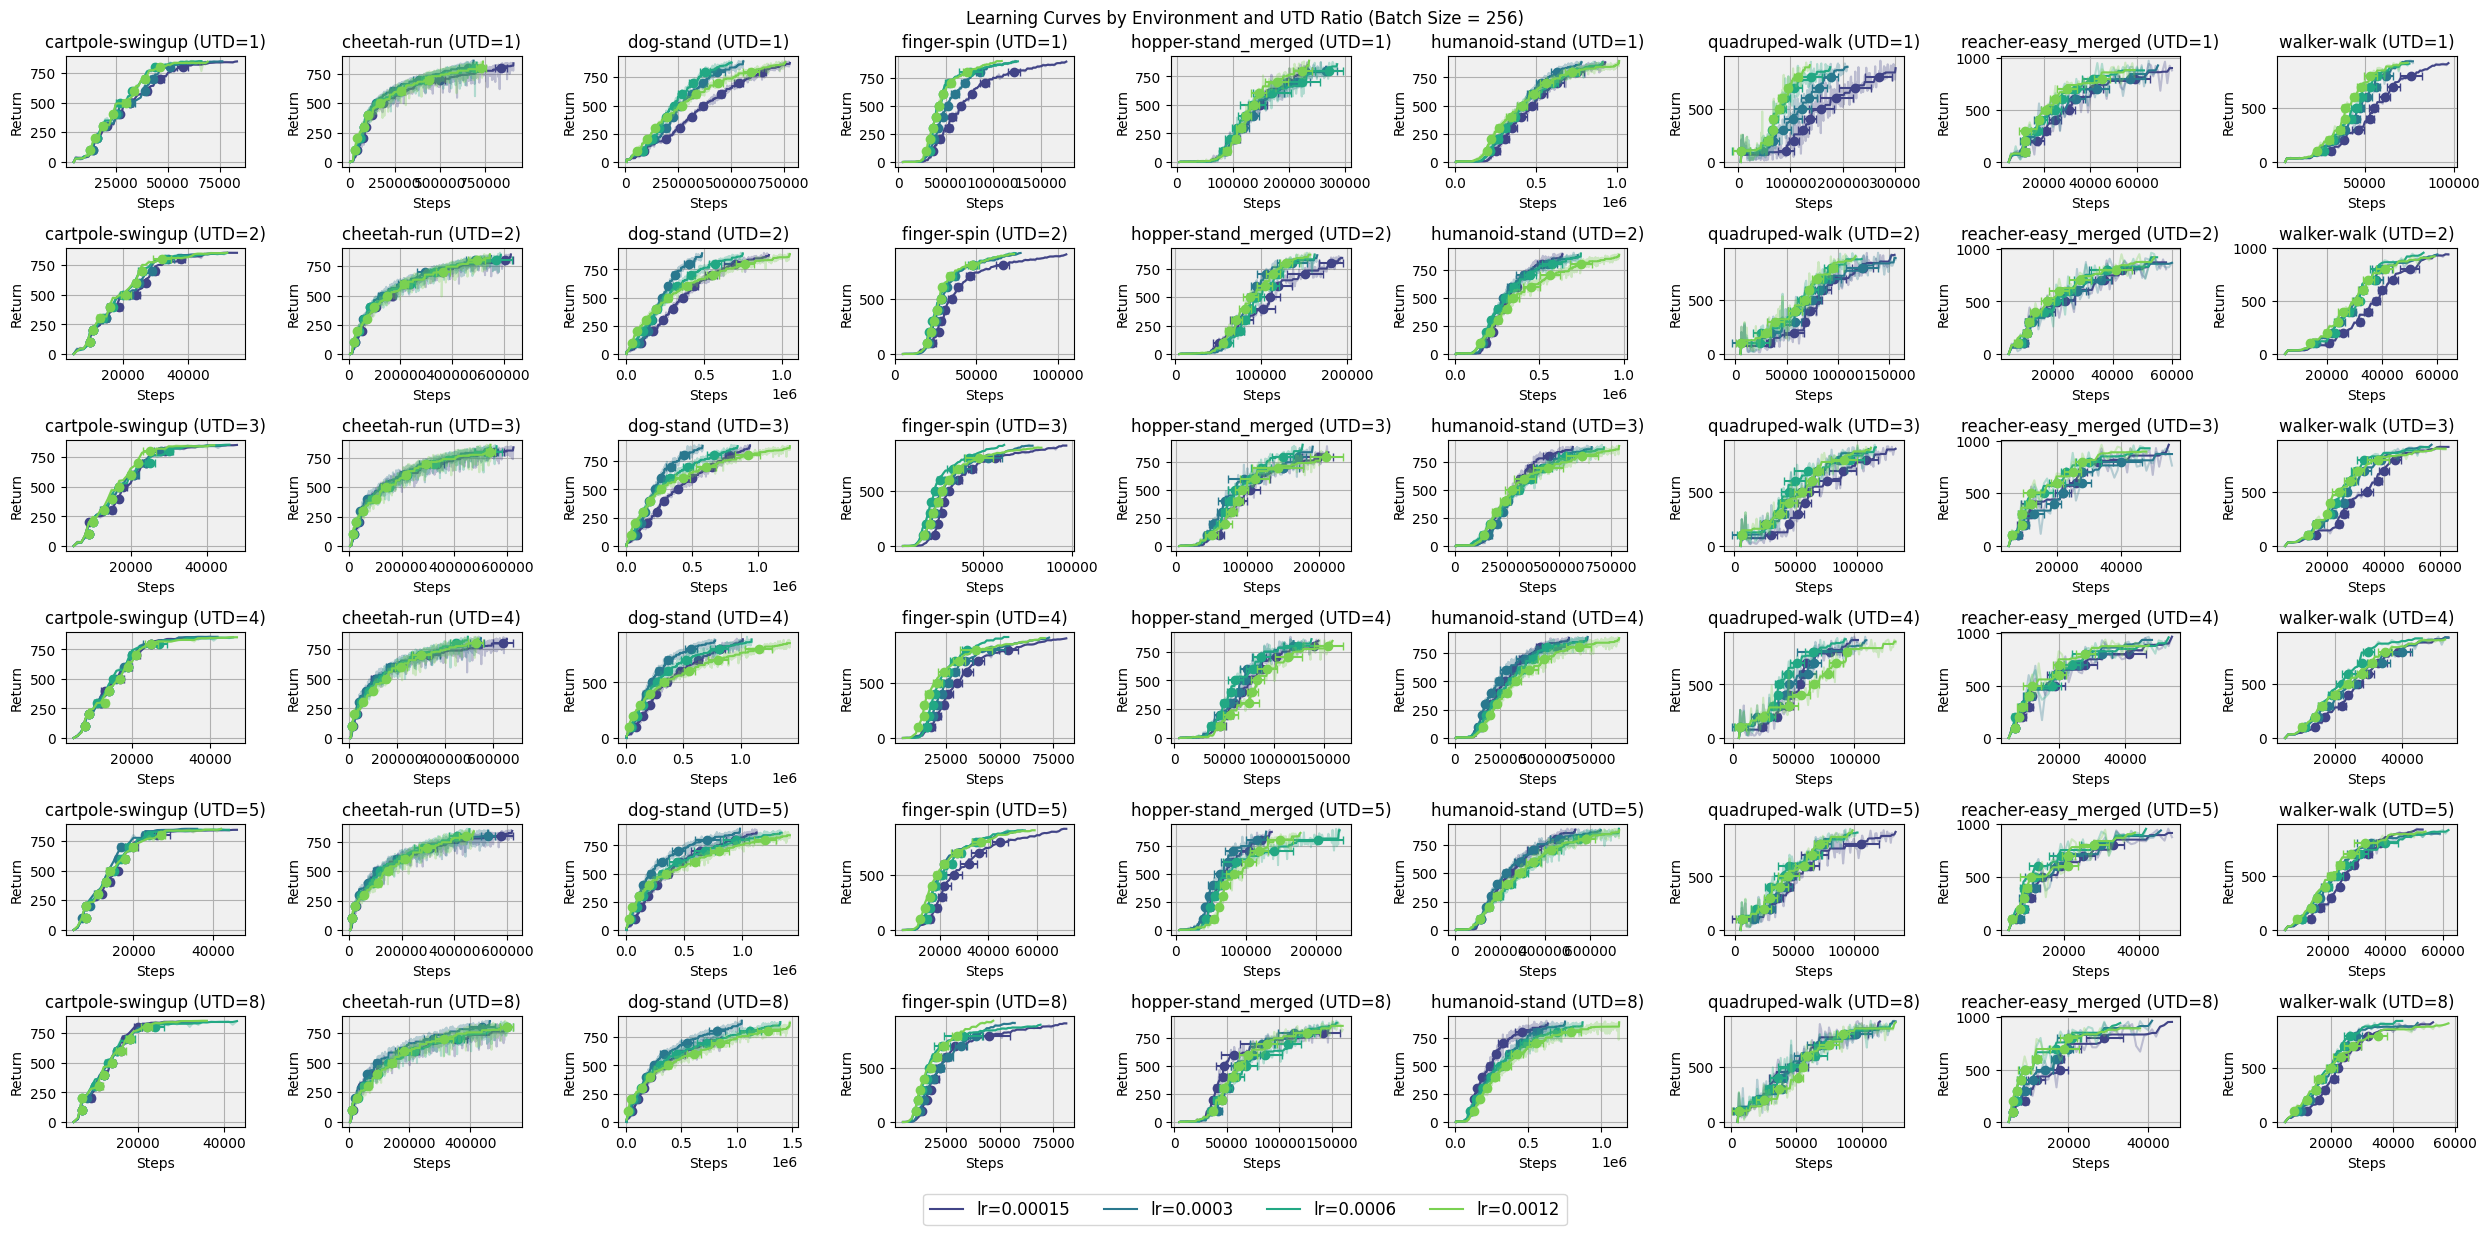

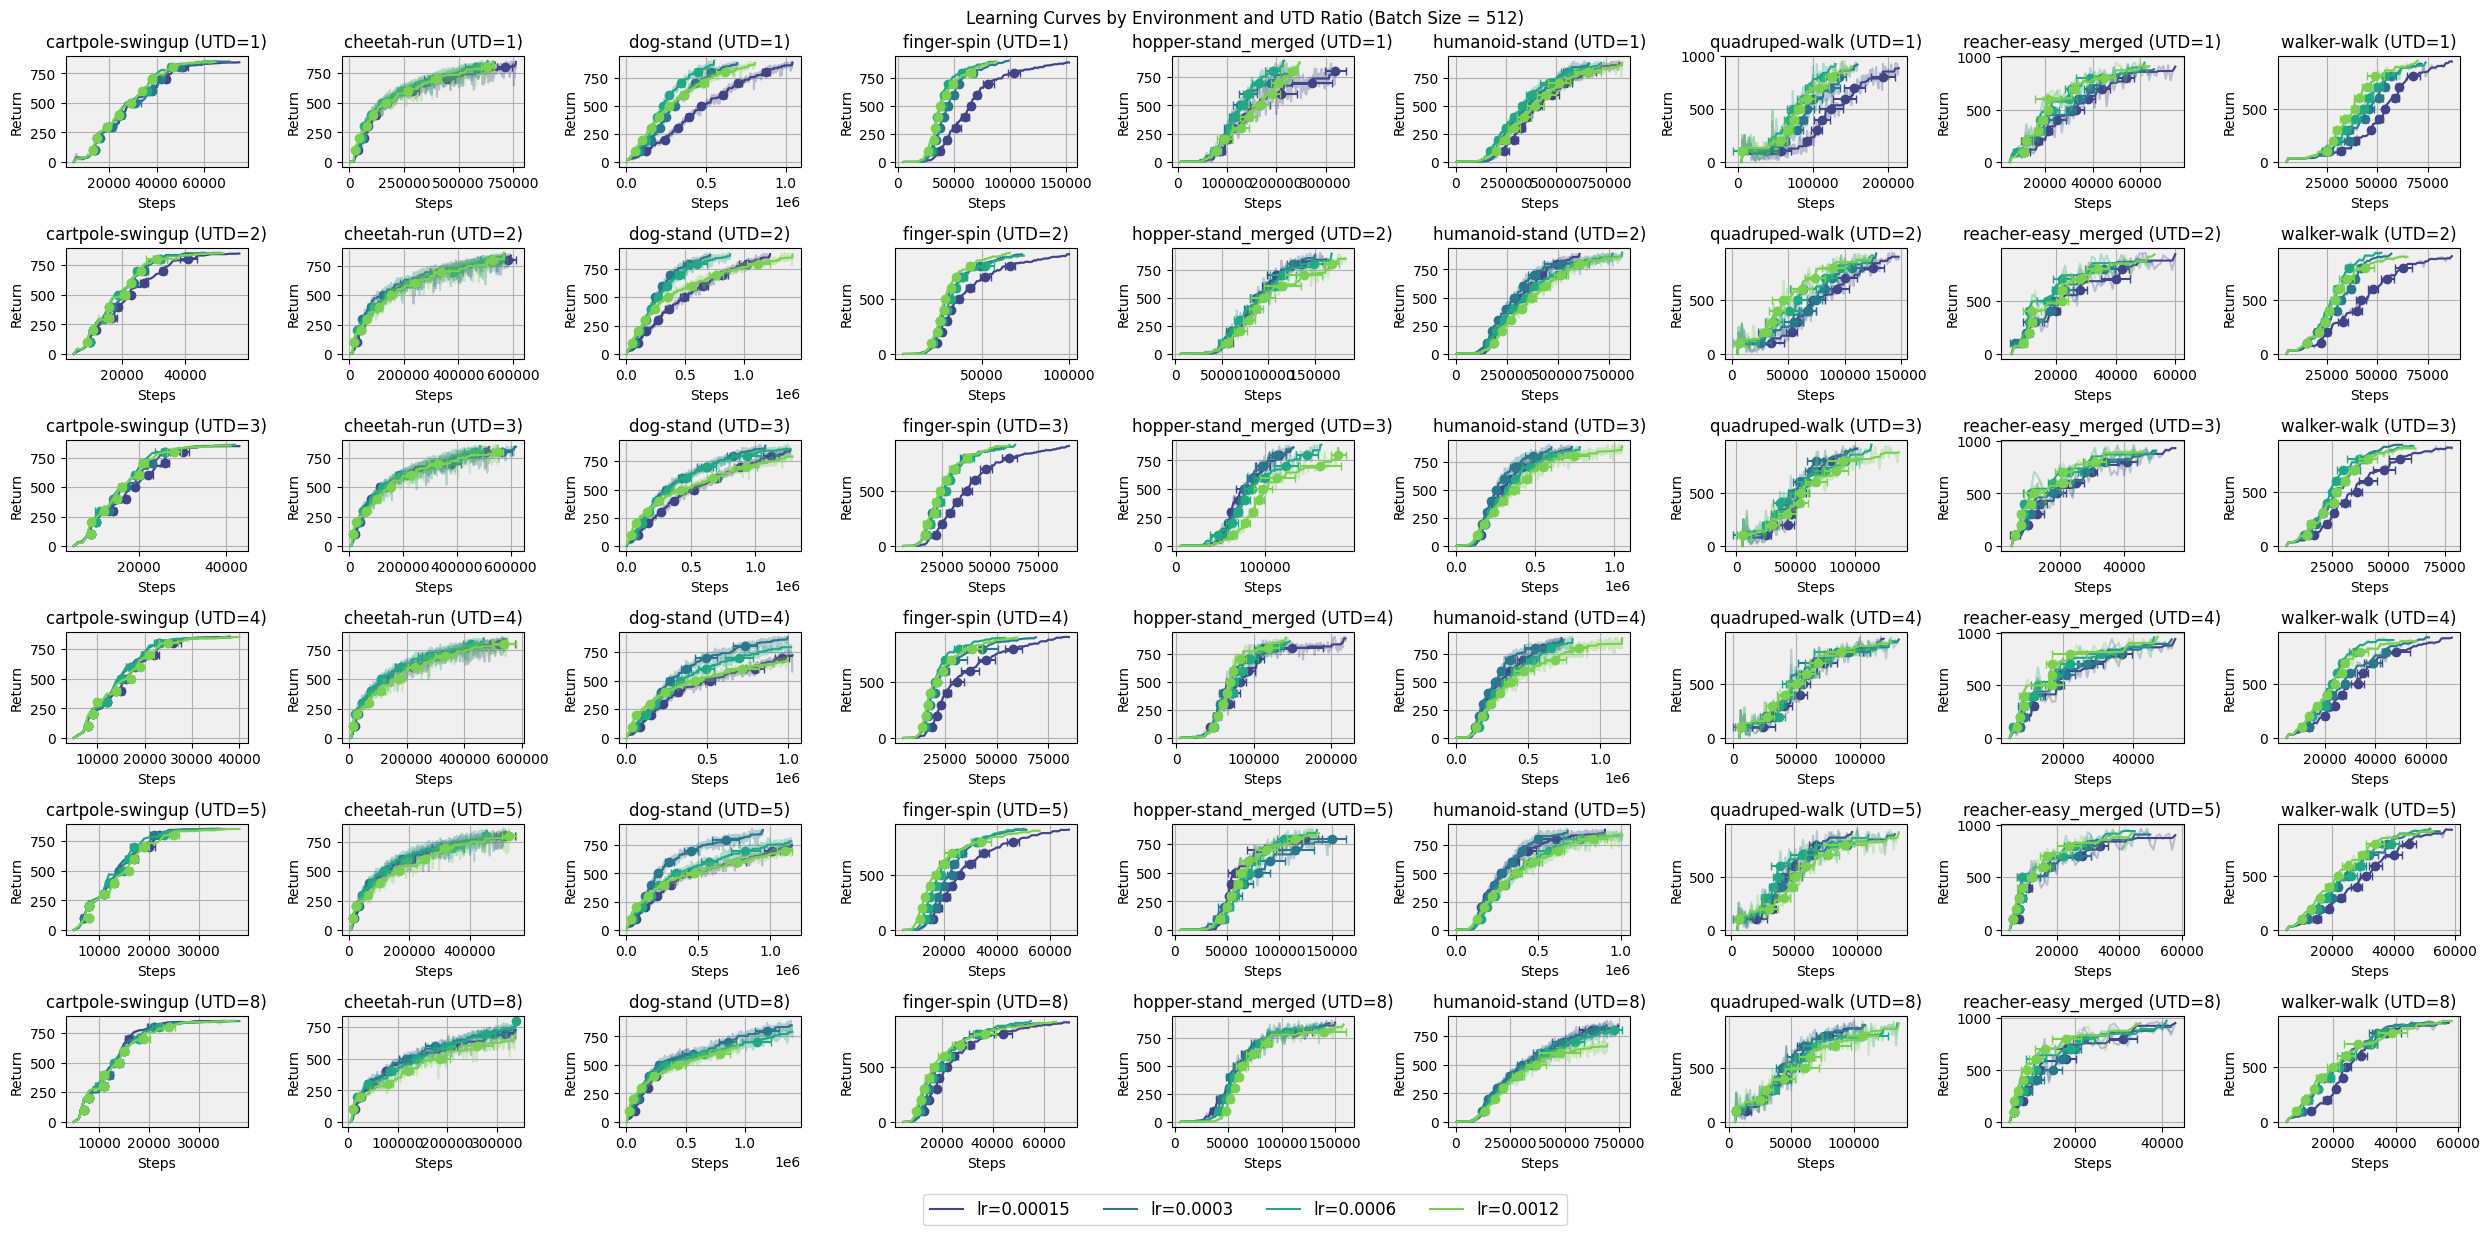

In [4]:
# plot curves

import matplotlib.pyplot as plt
import seaborn as sns

# Get unique batch sizes
batch_sizes = sorted(df['batch_size'].unique())

# Create a separate plot for each batch size
n_utds = len(df['utd'].unique())  # Number of UTD ratios to plot
n_envs = len(df['env_name'].unique())  # Number of environments to plot
for batch_size in batch_sizes:
    colors = sns.color_palette("viridis", n_colors=4)  # Using viridis for a nice gradient
    fig, axs = plt.subplots(n_utds, n_envs, figsize=(25, 12))
    fig.suptitle(f'Learning Curves by Environment and UTD Ratio (Batch Size = {batch_size})')

    lines = []
    labels = []
    config_colors = {}
    color_idx = 0

    # Filter data for current batch size
    df_filtered = df[df['batch_size'] == batch_size]

    # Group data by environment and UTD ratio
    for i, env in enumerate(sorted(df['env_name'].unique())):
        env_data = df_filtered[df_filtered['env_name'] == env]
        
        # Create separate plots for each UTD value
        for j, utd in enumerate(sorted(env_data['utd'].unique())):
            utd_data = env_data[env_data['utd'] == utd]
            # Sort by learning rate only since we're already filtering by UTD
            utd_data = utd_data.sort_values('learning_rate')
            
            ax = axs[j, i]
            ax.set_title(f'{env} (UTD={utd})')
            
            for _, row in utd_data.iterrows():
                config = row['learning_rate']
                if config not in config_colors:
                    config_colors[config] = color_idx
                    color_idx += 1
                
                label = f"lr={row['learning_rate']}"
                line = ax.plot(row['training_step'], row['mean_return'], alpha=0.3, color=colors[config_colors[config] % len(colors)])
                line = ax.plot(row['training_step'], row['return_isotonic'], alpha=1, color=colors[config_colors[config] % len(colors)])
                # results = scipy.ndimage.gaussian_filter1d(row['mean_return'], smoothing[env, row['utd']])
                # line = ax.plot(row['training_step'], results, alpha=1, color=colors[config_colors[config] % len(colors)])
                
                # use the crossings column to plot crossings
                for k, threshold in enumerate(thresholds):
                    # crossing_x = row['crossings'][k]
                    crossing_x = row['crossings'][k]
                    crossing_y = threshold
                    ax.plot(crossing_x, crossing_y, 'o', color=colors[config_colors[config] % len(colors)])
                # Plot crossing standard deviations as error bars
                for k, threshold in enumerate(thresholds):
                    crossing_x = row['crossings'][k]
                    crossing_y = threshold
                    crossing_std = row['crossings_std'][k]
                    ax.errorbar(crossing_x, crossing_y, xerr=crossing_std, fmt='none', color=colors[config_colors[config] % len(colors)], capsize=3)

                # Only add to legend if we haven't seen this combination before
                if label not in labels:
                    lines.append(line[0])
                    labels.append(label)
            
            ax.set_xlabel('Steps')
            ax.set_ylabel('Return')
            ax.grid(True)
            
            # Set background color
            ax.set_facecolor('#f0f0f0')

    # Sort labels by learning rate
    sorted_indices = [i for i, _ in sorted(enumerate(labels), 
                                         key=lambda x: float(x[1].replace("lr=","")))]
    lines = [lines[i] for i in sorted_indices]
    labels = [labels[i] for i in sorted_indices]

    # Create a single legend outside all subplots
    fig.legend(lines, labels, bbox_to_anchor=(0.5, 0), loc='upper center', ncol=(len(labels)), fontsize=12)
    plt.tight_layout()
    plt.show()

In [3]:
# # plot curves one figure per UTD

# import matplotlib.pyplot as plt
# import seaborn as sns

# # Get unique UTD values
# utd_values = sorted(df['utd'].unique())

# # Create a separate plot for each UTD value
# for utd in utd_values:
#     colors = sns.color_palette("viridis", n_colors=4)  # Using viridis for a nice gradient
#     fig, axs = plt.subplots(4, 7, figsize=(25, 12))
#     fig.suptitle(f'Learning Curves by Environment and Batch Size (UTD = {utd})')

#     lines = []
#     labels = []
#     config_colors = {}
#     color_idx = 0

#     # Filter data for current UTD
#     df_filtered = df[df['utd'] == utd]

#     # Group data by environment and batch size
#     for i, env in enumerate(sorted(df['env_name'].unique())):
#         env_data = df_filtered[df_filtered['env_name'] == env]
        
#         # Create separate plots for each batch size value
#         for j, batch_size in enumerate(sorted(env_data['batch_size'].unique())):
#             batch_data = env_data[env_data['batch_size'] == batch_size]
#             # Sort by learning rate only since we're already filtering by batch size
#             batch_data = batch_data.sort_values('learning_rate')
            
#             ax = axs[j, i]
#             ax.set_title(f'{env} (BS={batch_size})')
            
#             for _, row in batch_data.iterrows():
#                 config = row['learning_rate']
#                 if config not in config_colors:
#                     config_colors[config] = color_idx
#                     color_idx += 1
                
#                 label = f"lr={row['learning_rate']}"
#                 line = ax.plot(row['training_step'], row['mean_return'], alpha=0.3, color=colors[config_colors[config] % len(colors)])
#                 line = ax.plot(row['training_step'], row['return_isotonic'], alpha=1, color=colors[config_colors[config] % len(colors)])
#                 # results = scipy.ndimage.gaussian_filter1d(row['mean_return'], smoothing[env, row['utd']])
#                 # line = ax.plot(row['training_step'], results, alpha=1, color=colors[config_colors[config] % len(colors)])
                
#                 # use the crossings column to plot crossings
#                 for k, threshold in enumerate(thresholds):
#                     # crossing_x = row['crossings'][k]
#                     crossing_x = row['crossings'][k]
#                     crossing_y = threshold
#                     ax.plot(crossing_x, crossing_y, 'o', color=colors[config_colors[config] % len(colors)])
#                 # Plot crossing standard deviations as error bars
#                 for k, threshold in enumerate(thresholds):
#                     crossing_x = row['crossings'][k]
#                     crossing_y = threshold
#                     crossing_std = row['crossings_std'][k]
#                     ax.errorbar(crossing_x, crossing_y, xerr=crossing_std, fmt='none', color=colors[config_colors[config] % len(colors)], capsize=3)

#                 # Only add to legend if we haven't seen this combination before
#                 if label not in labels:
#                     lines.append(line[0])
#                     labels.append(label)
            
#             ax.set_xlabel('Steps')
#             ax.set_ylabel('Return')
#             ax.grid(True)
            
#             # Set background color
#             ax.set_facecolor('#f0f0f0')

#     # Sort labels by learning rate
#     sorted_indices = [i for i, _ in sorted(enumerate(labels), 
#                                          key=lambda x: float(x[1].replace("lr=","")))]
#     lines = [lines[i] for i in sorted_indices]
#     labels = [labels[i] for i in sorted_indices]

#     # Create a single legend outside all subplots
#     fig.legend(lines, labels, bbox_to_anchor=(0.5, 0), loc='upper center', ncol=(len(labels)), fontsize=12)
#     plt.tight_layout()
#     plt.show()

In [4]:
# # plot curves for all bs and lr together

# colors = sns.color_palette("viridis", n_colors=8)  # Using viridis for a nice gradient
# fig, axs = plt.subplots(4, 7, figsize=(25, 12))
# fig.suptitle('Learning Curves by Environment and UTD Ratio')

# lines = []
# labels = []
# config_colors = {}
# color_idx = 0

# df_filtered = df[df['batch_size'] == 64]
# df_filtered = df
# # df_filtered = df_filtered[df_filtered['learning_rate'] == 3e-4]

# # Group data by environment and UTD ratio
# for i, env in enumerate(df['env_name'].unique()):
#     env_data = df_filtered[df_filtered['env_name'] == env]
    
#     # Create separate plots for each UTD value
#     for j, utd in enumerate(env_data['utd'].unique()):
#         utd_data = env_data[env_data['utd'] == utd]
#         # Sort by batch size and learning rate
#         utd_data = utd_data.sort_values(['utd', 'batch_size', 'learning_rate'])
        
#         ax = axs[j, i]
#         ax.set_title(f'{env} (UTD={utd})')
        
#         for _, row in utd_data.iterrows():
#             config = (row['batch_size'], row['learning_rate'])
#             if config not in config_colors:
#                 config_colors[config] = color_idx
#                 color_idx += 1
            
#             label = f"bs={row['batch_size']}, lr={row['learning_rate']}"
#             line = ax.plot(row['training_step'], row['mean_return'], alpha=0.3, color=colors[config_colors[config] % len(colors)])
#             line = ax.plot(row['training_step'], row['return_isotonic'], alpha=1, color=colors[config_colors[config] % len(colors)])
#             # results = scipy.ndimage.gaussian_filter1d(row['mean_return'], smoothing[env, row['utd']])
#             # line = ax.plot(row['training_step'], results, alpha=1, color=colors[config_colors[config] % len(colors)])

#             # use the crossings column to plot crossings
#             # for k, threshold in enumerate(thresholds):
#             #     crossing_x = row['crossings'][k]
#             #     crossing_y = threshold
#             #     ax.plot(crossing_x, crossing_y, 'o', color=colors[config_colors[config] % len(colors)])
            
#             # Only add to legend if we haven't seen this combination before
#             if label not in labels:
#                 lines.append(line[0])
#                 labels.append(label)
        
#         ax.set_xlabel('Steps')
#         ax.set_ylabel('Return')
#         ax.grid(True)
        
#         # Set background color
#         ax.set_facecolor('#f0f0f0')

# # Sort labels by batch size and learning rate
# sorted_indices = [i for i, _ in sorted(enumerate(labels), 
#                                      key=lambda x: tuple(map(float, x[1].replace("bs=","").replace("lr=","").split(", "))))]
# lines = [lines[i] for i in sorted_indices]
# labels = [labels[i] for i in sorted_indices]

# # Create a single legend outside all subplots
# fig.legend(lines, labels, bbox_to_anchor=(0.5, 0), loc='upper center', ncol=(len(labels) // 3)+1, fontsize=12)
# plt.tight_layout()
# plt.show()

In [5]:
# # plot curves, split by learning rate

# import matplotlib.pyplot as plt
# import seaborn as sns

# # Get unique learning rates
# learning_rates = df['learning_rate'].unique()

# # Create a separate plot for each learning rate
# for lr in learning_rates:
#     colors = sns.color_palette("viridis", n_colors=4)  # Using viridis for a nice gradient
#     fig, axs = plt.subplots(4, 7, figsize=(25, 12))
#     fig.suptitle(f'Learning Curves by Environment and UTD Ratio (Learning Rate = {lr})')

#     lines = []
#     labels = []
#     config_colors = {}
#     color_idx = 0

#     # Filter data for current learning rate
#     df_filtered = df[df['learning_rate'] == lr]

#     # Group data by environment and UTD ratio
#     for i, env in enumerate(df['env_name'].unique()):
#         env_data = df_filtered[df_filtered['env_name'] == env]
        
#         # Create separate plots for each UTD value
#         for j, utd in enumerate(sorted(env_data['utd'].unique())):
#             utd_data = env_data[env_data['utd'] == utd]
#             # Sort by UTD
#             utd_data = utd_data.sort_values('batch_size')
            
#             ax = axs[j, i]
#             ax.set_title(f'{env} (UTD={utd})')
            
#             for _, row in utd_data.iterrows():
#                 config = row['batch_size']
#                 if config not in config_colors:
#                     config_colors[config] = color_idx
#                     color_idx += 1
                
#                 label = f"batch_size={row['batch_size']}"
#                 # Plot raw data with low alpha
#                 line = ax.plot(row['training_step'], row['mean_return'], alpha=0.3, color=colors[config_colors[config] % len(colors)])
#                 # Plot isotonic regression with full alpha
#                 line = ax.plot(row['training_step'], row['return_isotonic'], alpha=1, color=colors[config_colors[config] % len(colors)])

#                 # use the crossings column to plot crossings
#                 for k, threshold in enumerate(thresholds):
#                     crossing_x = row['crossings'][k]
#                     crossing_y = threshold
#                     ax.plot(crossing_x, crossing_y, 'o', color=colors[config_colors[config] % len(colors)])
                
#                 # Only add to legend if we haven't seen this combination before
#                 if label not in labels:
#                     lines.append(line[0])
#                     labels.append(label)
            
#             ax.set_xlabel('Steps')
#             ax.set_ylabel('Return')
#             ax.grid(True)
            
#             # Set background color
#             ax.set_facecolor('#f0f0f0')

#     # Sort labels by batch size
#     sorted_indices = [i for i, _ in sorted(enumerate(labels), 
#                                          key=lambda x: float(x[1].replace("batch_size=","")))]
#     lines = [lines[i] for i in sorted_indices]
#     labels = [labels[i] for i in sorted_indices] 

#     # Create a single legend outside all subplots
#     fig.legend(lines, labels, bbox_to_anchor=(0.5, 0), loc='upper center', ncol=(len(labels)), fontsize=12)
#     plt.tight_layout()
#     plt.show()

In [6]:
# # Plot learning rate vs performance for each environment, batch size and UTD
# unique_envs = sorted(df['env_name'].unique())
# unique_batch_sizes = sorted(df['batch_size'].unique()) 
# unique_utds = sorted(df['utd'].unique())

# for env in unique_envs:
#     # Create a new figure for each environment
#     cols = 4
#     rows = int(np.ceil(len(unique_batch_sizes) * len(unique_utds) / cols))
#     fig, axs = plt.subplots(rows, cols, figsize=(15, 3*rows))
#     axs = axs.flatten()
    
#     plot_idx = 0
#     env_data = df[df['env_name'] == env]
    
#     for utd in unique_utds:
#         for batch_size in unique_batch_sizes:
#             data = env_data[(env_data['batch_size'] == batch_size) & 
#                            (env_data['utd'] == utd)]
            
#             if len(data) == 0:
#                 continue
                
#             # Group by learning rate
#             lr_groups = data.groupby('learning_rate')
#             threshold_i = -1
#             threshold = thresholds[threshold_i]

#             time_to_threshold = lr_groups.apply(lambda x: np.mean([r[threshold_i] for r in x['crossings']]))
#             sem = lr_groups.apply(lambda x: np.mean([r[threshold_i] for r in x['crossings_std']]))
            
#             lrs = sorted(lr_groups.groups.keys())
#             means = [time_to_threshold[lr] for lr in lrs]
#             sems = [sem[lr] for lr in lrs]
            
#             axs[plot_idx].errorbar(lrs, means, yerr=sem, fmt='o-')
            
#             axs[plot_idx].set_xscale('log')
#             axs[plot_idx].set_xlabel('Learning Rate')
#             axs[plot_idx].set_ylabel('Time to {threshold}')
#             axs[plot_idx].set_title(f'batch_size={batch_size}, utd={utd}')
#             axs[plot_idx].grid(True)
            
#             plot_idx += 1
    
#     # Remove empty subplots
#     for i in range(plot_idx, len(axs)):
#         fig.delaxes(axs[i])
        
#     fig.suptitle(env, fontsize=16)
#     plt.tight_layout()
#     plt.show()


## Optimal learning rate and batch size 

In [7]:
# make and print a table with best learning rate for each environment, batch size and UTD
# with environment as rows and utd x batch size as columns

# Group data by environment, batch size and UTD
grouped = df.groupby(['env_name', 'batch_size', 'utd'])

# Find best learning rate for each group
results = []
for (env, bs, utd), group in grouped:
    threshold_i = -1
    # Group by learning rate and get time to threshold
    lr_groups = group.groupby('learning_rate')
    time_to_threshold = lr_groups.apply(lambda x: x['crossings'].iloc[0][threshold_i]).dropna()
    
    # Get bootstrap samples
    time_to_threshold_bs = lr_groups.apply(lambda x: x['crossings_bootstrap'].iloc[0][:, threshold_i])
    lrs = np.array(time_to_threshold_bs.index)
    times_bs = np.array(time_to_threshold_bs.tolist())
    
    # Find best learning rates
    times_bs_inf = np.where(np.isnan(times_bs), np.inf, times_bs)
    best_lr_bootstrap = lrs[np.argmin(times_bs_inf, axis=0)]
    best_times_bootstrap = np.min(times_bs_inf, axis=0)
    
    # Get point estimates
    best_lr = time_to_threshold.idxmin() if len(time_to_threshold) > 0 else None
    min_time = time_to_threshold[best_lr] if best_lr is not None else None

    results.append({
        'env_name': env,
        'batch_size': bs,
        'utd': utd,
        'best_lr': best_lr,
        'time_to_threshold': min_time,
        'best_lr_bootstrap': best_lr_bootstrap, # run learning rate selection 100 times and record best learning rate
        'time_to_threshold_bootstrap': best_times_bootstrap, # run learning rate selection 100 times and record corresponding time to threshold
    })

# Create DataFrame
df_best_lr = pd.DataFrame(results)

# Pivot table to get environments as rows and utd x batch_size as columns
pivot_df = df_best_lr.pivot_table(
    index='utd',
    columns=['env_name', 'batch_size'],
    values='best_lr',
    aggfunc='first'
)

# Print formatted table with scientific notation
pd.set_option('display.float_format', '{:.1e}'.format)
print("\nBest Learning Rates:")
print(pivot_df.to_string())

# now do the same for uncertainty-corrected best learning rates
# Create pivot table for uncertainty-corrected best learning rates
# Use mean of bootstrap samples as uncertainty-corrected estimate
pivot_df_bootstrap = df_best_lr.pivot_table(
    index='utd',
    columns=['env_name', 'batch_size'],
    values='best_lr_bootstrap',
    aggfunc=lambda x: np.mean(np.stack(x))
)

# Print formatted table with scientific notation
print("\nUncertainty-Corrected Best Learning Rates:")
print(pivot_df_bootstrap.to_string())






Best Learning Rates:
env_name   cartpole-swingup                                 cheetah-run                                 dog-stand                                 finger-spin                                 hopper-stand_merged                                 humanoid-stand                                 quadruped-walk                                 reacher-easy_merged                                 walker-walk                                
batch_size              32      64      128     256     512         32      64      128     256     512       32      64      128     256     512         32      64      128     256     512                 32      64      128     256     512            32      64      128     256     512            32      64      128     256     512                 32      64      128     256     512         32      64      128     256     512
utd                                                                                                               

In [8]:
# Find best batch size for each env/utd/lr combination based on minimum time to threshold
best_bs_results = []
for (env, utd, lr), group in df.groupby(['env_name', 'utd', 'learning_rate']):
    # Drop any rows where crossings[-1] is None
    group = group.dropna(subset=['crossings'])
    
    if len(group) > 0:
        # Get the last crossing time for each row and bootstrap samples
        group['last_crossing'] = group['crossings'].apply(lambda x: x[-1] if len(x) > 0 else float('inf'))
        group['last_crossing_bootstrap'] = group['crossings_bootstrap'].apply(lambda x: x[:, -1])
        
        # Get batch sizes and times for bootstrap analysis
        batch_sizes = np.array(group['batch_size'])
        times_bs = np.stack(group['last_crossing_bootstrap'])
        
        # Find best batch sizes
        times_bs_inf = np.where(np.isnan(times_bs), np.inf, times_bs)
        best_bs_bootstrap = batch_sizes[np.argmin(times_bs_inf, axis=0)]
        best_times_bootstrap = np.min(times_bs_inf, axis=0)
        
        # Get point estimates
        best_bs = group.loc[group['last_crossing'].idxmin(), 'batch_size']
        min_time = group['last_crossing'].min()
        
        best_bs_results.append({
            'env_name': env,
            'utd': utd,
            'learning_rate': lr,
            'best_bs': best_bs,
            'time_to_threshold': min_time,
            'best_bs_bootstrap': best_bs_bootstrap,
            'time_to_threshold_bootstrap': best_times_bootstrap
        })

# Create DataFrame
df_best_bs = pd.DataFrame(best_bs_results)

# Pivot table to show best batch sizes by environment and UTD, with learning rates as columns
pivot_bs = df_best_bs.pivot_table(
    index=['utd'],
    columns=['env_name', 'learning_rate'],
    values='best_bs',
    aggfunc='first'
)

print("\nBest Batch Sizes:")
print(pivot_bs.to_string())

# Also show corresponding times to threshold
pivot_times = df_best_bs.pivot_table(
    index=['utd'],
    columns=['env_name', 'learning_rate'], 
    values='time_to_threshold',
    aggfunc='first'
)

print("\nCorresponding Times to Threshold:")
print(pivot_times.to_string())



Best Batch Sizes:
env_name      cartpole-swingup                         cheetah-run                         dog-stand                         finger-spin                         hopper-stand_merged                         humanoid-stand                         quadruped-walk                         reacher-easy_merged                         walker-walk                        
learning_rate          1.5e-04 3.0e-04 6.0e-04 1.2e-03     1.5e-04 3.0e-04 6.0e-04 1.2e-03   1.5e-04 3.0e-04 6.0e-04 1.2e-03     1.5e-04 3.0e-04 6.0e-04 1.2e-03             1.5e-04 3.0e-04 6.0e-04 1.2e-03        1.5e-04 3.0e-04 6.0e-04 1.2e-03        1.5e-04 3.0e-04 6.0e-04 1.2e-03             1.5e-04 3.0e-04 6.0e-04 1.2e-03     1.5e-04 3.0e-04 6.0e-04 1.2e-03
utd                                                                                                                                                                                                                                                            

In [9]:
# # for each utd and env, plot best learning rate depending on batch size
# # Plot best learning rate vs batch size for each UTD and environment
# unique_envs = sorted(df['env_name'].unique())
# unique_utds = sorted(df['utd'].unique())

# fig, axs = plt.subplots(len(unique_utds), len(unique_envs), figsize=(25, 15))
# fig.suptitle('Best Learning Rate vs Batch Size')

# for i, env in enumerate(unique_envs):
#     for j, utd in enumerate(unique_utds):
#         env_data = df_best_lr[
#             (df_best_lr['env_name'] == env) & 
#             (df_best_lr['utd'] == utd)
#         ]
        
#         if len(env_data) > 0:
#             batch_sizes = env_data['batch_size']
#             best_lrs = env_data['best_lr']
            
#             axs[j, i].plot(batch_sizes, best_lrs, 'o-')
#             axs[j, i].set_xscale('log')
#             axs[j, i].set_yscale('log')
#             axs[j, i].set_ylim(1.3e-4, 1.3e-3)
#             axs[j, i].set_xlabel('Batch Size')
#             axs[j, i].set_ylabel('Best Learning Rate')
#             axs[j, i].set_title(f'{env}, UTD={utd}')
#             axs[j, i].grid(True)

# plt.tight_layout()
# plt.show()



In [10]:
# # Plot best learning rate vs UTD for each batch size and environment
# unique_envs = sorted(df['env_name'].unique())
# unique_batch_sizes = sorted(df['batch_size'].unique())

# fig, axs = plt.subplots(len(unique_batch_sizes), len(unique_envs), figsize=(25, 15))
# fig.suptitle('Best Learning Rate vs UTD')

# for i, env in enumerate(unique_envs):
#     for j, bs in enumerate(unique_batch_sizes):
#         env_data = df_best_lr[
#             (df_best_lr['env_name'] == env) & 
#             (df_best_lr['batch_size'] == bs)
#         ]
        
#         if len(env_data) > 0:
#             utds = env_data['utd']
#             best_lrs = env_data['best_lr']
            
#             axs[j, i].plot(utds, best_lrs, 'o-')
#             axs[j, i].set_xscale('log')
#             axs[j, i].set_yscale('log')
#             axs[j, i].set_ylim(1.3e-4, 1.3e-3)
#             axs[j, i].set_xlabel('UTD')
#             axs[j, i].set_ylabel('Best Learning Rate')
#             axs[j, i].set_title(f'{env}, BS={bs}')
#             axs[j, i].grid(True)

# plt.tight_layout()
# plt.show()

In [11]:
# # Plot time to threshold vs batch size using optimal learning rates
# unique_envs = sorted(df['env_name'].unique())
# unique_utds = sorted(df['utd'].unique())

# rows = len(unique_utds)
# cols = len(unique_envs)
# fig, axs = plt.subplots(rows, cols, figsize=(4*cols, 3*rows))

# for row, utd in enumerate(unique_utds):
#     for col, env in enumerate(unique_envs):
#         env_data = df[(df['env_name'] == env) & (df['utd'] == utd)]
        
#         # For each batch size, get data for optimal learning rate
#         batch_sizes = sorted(env_data['batch_size'].unique())
#         means = []
#         sems = []
#         best_lrs = []
        
#         for bs in batch_sizes:
#             batch_data = env_data[env_data['batch_size'] == bs]
            
#             # Get data for optimal learning rate
#             threshold_i = -1
#             threshold = thresholds[threshold_i]
            
#             times = [r[threshold_i] for r in batch_data['crossings']]
#             errors = [r[threshold_i] for r in batch_data['crossings_std']]
#             lrs = batch_data['learning_rate'].values
            
#             # Find minimum mean time across learning rates
#             min_idx = np.argmin([np.mean(t) for t in times])
#             means.append(np.mean(times[min_idx]))
#             sems.append(np.mean(errors[min_idx]))
#             best_lrs.append(lrs[min_idx])

#         if env == 'dog-stand' and utd == 8:
#             print(env, utd, best_lrs, means, min_idx)
#         line = axs[row,col].errorbar(batch_sizes, means, yerr=sems, fmt='o-')
#         axs[row,col].set_xscale('log')
        
#         # Add learning rate annotations
#         for i, (bs, lr) in enumerate(zip(batch_sizes, best_lrs)):
#             axs[row,col].annotate(f'{lr:.1e}', 
#                                 (bs, means[i]),
#                                 xytext=(5, 5), 
#                                 textcoords='offset points',
#                                 fontsize=8)
        
#         # Only add x-label for bottom row
#         if row == rows-1:
#             axs[row,col].set_xlabel('Batch Size')
        
#         # Only add y-label for leftmost column    
#         if col == 0:
#             axs[row,col].set_ylabel(f'Time to {threshold}')
            
#         # Add environment name as title for top row, UTD for all rows
#         if row == 0:
#             axs[row,col].set_title(f'{env}')
#         axs[row,col].set_title(f'{env}\nUTD={utd}', pad=10)
#         axs[row,col].grid(True)

# plt.tight_layout()
# plt.show()


In [12]:
# # for each utd and env, plot best learning rate depending on batch size
# # Plot best learning rate vs batch size for each UTD and environment
# unique_envs = sorted([env for env in df['env_name'].unique() if env != 'hopper-stand'])
# unique_utds = sorted(df['utd'].unique())

# fig, axs = plt.subplots(len(unique_utds), len(unique_envs), figsize=(25, 15))
# fig.suptitle('Best Learning Rate vs Batch Size')

# for i, env in enumerate(unique_envs):
#     for j, utd in enumerate(unique_utds):
#         env_data = df_best_lr[
#             (df_best_lr['env_name'] == env) & 
#             (df_best_lr['utd'] == utd)
#         ]
        
#         if len(env_data) > 0:
#             batch_sizes = env_data['batch_size']
#             best_lrs = env_data['best_lr']
            
#             axs[j, i].plot(batch_sizes, best_lrs, 'o-')
#             # Add error bars from bootstrap samples
#             best_lrs_bootstrap = env_data['best_lr_bootstrap']
#             best_lrs_mean = np.mean(np.stack(best_lrs_bootstrap), axis=1)
#             best_lrs_std = np.std(np.stack(best_lrs_bootstrap), axis=1)
#             axs[j, i].errorbar(batch_sizes, best_lrs_mean, yerr=best_lrs_std, fmt='o-', alpha=0.4)
#             axs[j, i].set_xscale('log')
#             axs[j, i].set_yscale('log')
#             axs[j, i].set_ylim(1.3e-4, 1.3e-3)
#             axs[j, i].set_xlabel('Batch Size')
#             axs[j, i].set_ylabel('Best Learning Rate')
#             axs[j, i].set_title(f'{env}, UTD={utd}')
#             axs[j, i].grid(True)

# plt.tight_layout()
# plt.show()

## Correlation analysis

In [13]:
# Calculate correlation between batch size and best learning rate for each env/utd combination
correlations = []
for (env, utd), group in df_best_lr.groupby(['env_name', 'utd']):
    # Skip hopper-stand and reacher-easy
    # if env in ['hopper-stand', 'reacher-easy']:
    #     continue
        
    # Drop any rows where best_lr is None
    group = group.dropna(subset=['best_lr'])
    
    if len(group) > 1:  # Need at least 2 points for correlation
        correlation = np.corrcoef(np.log(group['batch_size']), np.log(group['best_lr']))[0,1]
        correlations.append({
            'env_name': env,
            'utd': utd,
            'correlation': correlation
        })

# Create DataFrame of correlations
corr_df = pd.DataFrame(correlations)

# Pivot table to show correlations by environment and UTD
pivot_corr = corr_df.pivot_table(
    index='env_name',
    columns='utd',
    values='correlation',
    aggfunc='first'
).T

print("\nCorrelations between log batch size and log learning rate:")
print(pivot_corr.to_string())

# Calculate mean correlation per environment
env_correlations = corr_df.groupby('env_name')['correlation'].mean()
print("\nMean correlations by environment:")
print(env_correlations.to_frame().T.to_string())


# Calculate mean correlation across all environments/UTDs
mean_correlation = np.nanmean([c['correlation'] for c in correlations])
print(f"\nMean correlation: {mean_correlation:.4f}")



Correlations between log batch size and log learning rate:
env_name  cartpole-swingup  cheetah-run  dog-stand  finger-spin  hopper-stand_merged  humanoid-stand  quadruped-walk  reacher-easy_merged  walker-walk
utd                                                                                                                                                   
1                 -8.7e-01     -4.3e-01    8.7e-01     -2.9e-01              4.2e-01         2.2e-01        -7.1e-01             -1.9e-01      7.1e-01
2                  7.1e-01      5.7e-01    7.1e-01      9.4e-01              1.4e-01        -7.6e-01         8.9e-01             -3.8e-01     -8.7e-01
3                 -2.2e-01      2.2e-17        NaN     -4.5e-01              5.7e-01        -5.7e-01        -3.5e-01              2.2e-01     -5.8e-01
4                 -2.4e-01      8.7e-01        NaN      8.7e-01             -4.3e-01        -4.9e-01        -2.2e-01              4.5e-01          NaN
5                  2.9e-01      7.

/home/oleh/miniconda3/envs/rlgpu/lib/python3.7/site-packages/numpy/lib/function_base.py:2691: RuntimeWarning: invalid value encountered in true_divide
  c /= stddev[:, None]
/home/oleh/miniconda3/envs/rlgpu/lib/python3.7/site-packages/numpy/lib/function_base.py:2692: RuntimeWarning: invalid value encountered in true_divide
  c /= stddev[None, :]


In [14]:
# Calculate correlation between UTD and best learning rate for each env/batch_size combination
correlations_utd = []
for (env, bs), group in df_best_lr.groupby(['env_name', 'batch_size']):
    # Drop any rows where best_lr is None
    # if env in ['hopper-stand', 'reacher-easy']:
    #     continue
    group = group.dropna(subset=['best_lr'])
    
    if len(group) > 1:  # Need at least 2 points for correlation
        correlation = np.corrcoef(np.log(group['utd']), np.log(group['best_lr']))[0,1]
        correlations_utd.append({
            'env_name': env,
            'batch_size': bs,
            'correlation': correlation
        })

# Create DataFrame of correlations
corr_df_utd = pd.DataFrame(correlations_utd)

# Pivot table to show correlations by environment and batch size
pivot_corr_utd = corr_df_utd.pivot_table(
    index='env_name',
    columns='batch_size', 
    values='correlation',
    aggfunc='first'
).T

print("\nCorrelations between log UTD and log learning rate:")
print(pivot_corr_utd.to_string())

# Calculate mean correlation per environment
env_correlations_utd = corr_df_utd.groupby('env_name')['correlation'].mean()
print("\nMean correlations by environment:")
print(env_correlations_utd.to_frame().T.to_string())


# Calculate mean correlation across all environments/batch sizes
mean_correlation_utd = np.nanmean([c['correlation'] for c in correlations_utd])
print(f"\nMean correlation: {mean_correlation_utd:.4f}")



Correlations between log UTD and log learning rate:
env_name    cartpole-swingup  cheetah-run  dog-stand  finger-spin  hopper-stand_merged  humanoid-stand  quadruped-walk  reacher-easy_merged  walker-walk
batch_size                                                                                                                                              
32                  -8.0e-01     -5.0e-01    6.0e-01     -3.4e-01             -2.0e-01         2.6e-01        -1.6e-01             -6.4e-01     -3.2e-01
64                  -7.9e-01      4.2e-01        NaN     -8.2e-01              3.2e-01        -7.1e-01        -4.9e-01             -2.4e-01     -6.9e-01
128                 -6.2e-01      1.2e-01        NaN     -5.6e-01             -1.0e-01        -8.5e-01        -7.7e-01              1.1e-02     -7.9e-01
256                 -6.6e-01      3.7e-01   -7.7e-01     -3.3e-01             -9.0e-01        -7.7e-01        -6.0e-02             -1.9e-01     -3.6e-01
512                 -7.9e-01 

/home/oleh/miniconda3/envs/rlgpu/lib/python3.7/site-packages/numpy/lib/function_base.py:2691: RuntimeWarning: invalid value encountered in true_divide
  c /= stddev[:, None]
/home/oleh/miniconda3/envs/rlgpu/lib/python3.7/site-packages/numpy/lib/function_base.py:2692: RuntimeWarning: invalid value encountered in true_divide
  c /= stddev[None, :]


In [17]:
from rliable import plot_utils
COLORS = ['#BBCC33', '#77AADD', '#44BB99',
           '#EEDD88', '#EE8866', '#FFAABB',
          '#99DDFF', '#44BB99', '#AAAA00',
          '#DDDDDD']
palette = sns.set_palette(COLORS)
plt.rcParams['text.usetex'] = False #Let TeX do the typsetting
plt.rcParams['text.latex.preamble'] = r'\usepackage{sansmath} \sansmath' #Force sans-serif math mode (for axes labels)
plt.rcParams['font.family'] = 'sans-serif' # ... for regular text
plt.rcParams['font.sans-serif'] = ['Helveta Nue'] # Choose a nice font here
sns.set_style("whitegrid")


Text(-0.025, 1.02, '×1e-4')

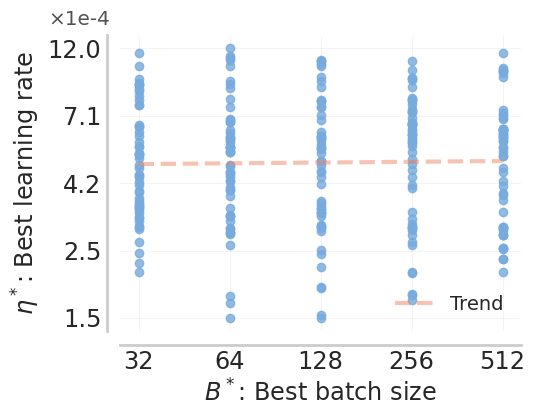

In [120]:
# Create scatter plots of optimal learning rate vs batch size for each environment
fig, axs = plt.subplots(1, 1)
fig.set_size_inches(496.0/192*2, 369.6/192*2)

# Collect all data points first
all_batch_sizes = []
all_lr_means = []

# Gather data from all environments
for env_name, group in df_best_lr.groupby('env_name'):
    # Drop rows where best_lr is None
    group = group.dropna(subset=['best_lr_bootstrap'])
    
    # Calculate mean from bootstrap samples
    best_lr_mean = group['best_lr_bootstrap'].apply(np.mean)
    
    all_batch_sizes.extend(group['batch_size'])
    all_lr_means.extend(best_lr_mean)

# Plot all points together
plt.scatter(all_batch_sizes, all_lr_means, marker='o', color=COLORS[1], alpha=0.8)

# Fit a line to the log-transformed data
log_bs = np.log(all_batch_sizes)
log_lr = np.log(all_lr_means)

# Remove any NaN values
mask = ~np.isnan(log_bs) & ~np.isnan(log_lr)
log_bs = log_bs[mask]
log_lr = log_lr[mask]

# Fit line
slope, intercept = np.polyfit(log_bs, log_lr, 1)

# Generate points for the fit line
x_fit = np.array([min(log_bs), max(log_bs)])
y_fit = slope * x_fit + intercept

# Plot the fit line
plt.plot(np.exp(x_fit), np.exp(y_fit), '--', color=COLORS[4], linewidth=3, label='Trend', alpha=0.5)

plt.xscale('log')
plt.yscale('log')
axs.legend(prop={'size': 14}, ncol=1, frameon=False, loc='lower right')

x = np.round(np.logspace(np.log10(min(all_batch_sizes)), np.log10(max(all_batch_sizes)), num=5))
x_ticks_labels = [f"{int(x)}" for x in x]
axs.set_xticks(x, x_ticks_labels)

y = np.logspace(np.log10(min(all_lr_means)), np.log10(max(all_lr_means)), num=5)
y_ticks_labels = [f"{y*1e4:.1f}" for y in y]
axs.set_yticks(y, y_ticks_labels, size=14.5)
axs.yaxis.set_minor_locator(plt.NullLocator())

plot_utils._annotate_and_decorate_axis(axs, xlabel='$B^*$: Best batch size',
                                      ylabel='$\eta^*$: Best learning rate',
                                      labelsize='xx-large', ticklabelsize='xx-large',
                                      grid_alpha=0.2, legend=False)

plt.text(-0.025, 1.02, '×1e-4', transform=axs.transAxes,
         horizontalalignment='right', verticalalignment='bottom', 
         fontsize='x-large', alpha=0.8)


In [39]:
# Corrleation between batch size and learning rate 
correlations = []
for env in df_best_bs['env_name'].unique():
    # if env in ['hopper-stand', 'reacher-easy']:
    #     continue
    for utd in df_best_bs['utd'].unique():
        env_utd_data = df_best_bs[(df_best_bs['env_name'] == env) & (df_best_bs['utd'] == utd)]
        if len(env_utd_data) > 1:  # Need at least 2 points for correlation
            corr = np.corrcoef(np.log(env_utd_data['best_bs']), 
                             np.log(env_utd_data['learning_rate']))[0,1]
            correlations.append({'env_name': env, 'utd': utd, 'correlation': corr})

# Show as table
corr_table = pd.DataFrame(correlations).pivot(index='env_name', columns='utd', values='correlation').T
print("\nCorrelations by environment and UTD:")
print(corr_table.to_string())

# Calculate mean correlation across all environments/UTDs
mean_correlation = np.nanmean([c['correlation'] for c in correlations])
print(f"\nMean correlation: {mean_correlation:.4f}")



Correlations by environment and UTD:
env_name  cartpole-swingup  cheetah-run  dog-stand  finger-spin  hopper-stand_merged  humanoid-stand  quadruped-walk  reacher-easy_merged  walker-walk
utd                                                                                                                                                   
1                 -9.1e-01          NaN    2.6e-01          NaN              2.6e-01             NaN        -7.7e-01             -4.5e-01          NaN
2                 -4.0e-01     -4.5e-01   -5.2e-17      5.2e-17             -8.9e-01        -2.6e-01         1.3e-01              1.8e-01      2.6e-01
3                 -5.2e-17     -4.5e-01   -2.6e-01      7.7e-01                  NaN        -2.6e-01        -8.9e-01              5.2e-17      2.6e-01
4                 -4.0e-01     -1.3e-01   -7.7e-01     -1.3e-01              4.5e-01        -2.6e-01         7.7e-01             -8.6e-02     -1.3e-01
5                 -7.7e-01      3.2e-01   -7.7e-01      

/home/oleh/miniconda3/envs/rlgpu/lib/python3.7/site-packages/numpy/lib/function_base.py:2691: RuntimeWarning: invalid value encountered in true_divide
  c /= stddev[:, None]
/home/oleh/miniconda3/envs/rlgpu/lib/python3.7/site-packages/numpy/lib/function_base.py:2692: RuntimeWarning: invalid value encountered in true_divide
  c /= stddev[None, :]


In [40]:
# Calculate correlation between log batch size and log UTD for each learning rate

# Calculate correlations for each environment and learning rate separately
correlations = []
for env in df_best_bs['env_name'].unique():
    # if env in ['hopper-stand', 'reacher-easy']:
    #     continue
        
    for lr in df_best_bs['learning_rate'].unique():
        env_lr_data = df_best_bs[(df_best_bs['env_name'] == env) & 
                                (df_best_bs['learning_rate'] == lr)]
        
        if len(env_lr_data) > 1:  # Need at least 2 points for correlation
            corr = np.corrcoef(np.log(env_lr_data['best_bs']), 
                             np.log(env_lr_data['utd']))[0,1]
            correlations.append({
                'env_name': env,
                'learning_rate': lr, 
                'correlation': corr
            })

# Show as table
corr_df = pd.DataFrame(correlations).pivot(
    index='env_name',
    columns='learning_rate',
    values='correlation'
).T
print("\nCorrelations by environment and learning rate:")
print(corr_df.to_string())

# Show per-environment correlations
print("\nCorrelations by environment:")
env_corr_df = corr_df.mean()
print(env_corr_df.to_frame().T.to_string())

# Calculate mean correlation across all environments and learning rates
mean_correlation = np.nanmean([c['correlation'] for c in correlations])
print(f"\nMean correlation: {mean_correlation:.4f}")

# Calculate correlations for each environment separately
env_correlations = []
for env in df_best_bs['env_name'].unique():
    data = df_best_bs[df_best_bs['env_name'] == env]
    if len(data) > 1:
        corr = np.corrcoef(np.log(data['best_bs']), np.log(data['utd']))[0,1]
        env_correlations.append({'env_name': env, 'correlation': corr})
mean_env_correlation = np.nanmean([c['correlation'] for c in env_correlations])
print(f"\nMean correlation across environments: {mean_env_correlation:.4f}")


# Calculate correlations for each UTD separately
utd_correlations = []
for utd in df_best_bs['utd'].unique():
    data = df_best_bs[df_best_bs['utd'] == utd]
    if len(data) > 1:  # Need at least 2 points for correlation
        corr = np.corrcoef(np.log(data['best_bs']), 
                          np.log(data['learning_rate']))[0,1]
        utd_correlations.append({
            'utd': utd,
            'correlation': corr
        })
mean_utd_correlation = np.nanmean([c['correlation'] for c in utd_correlations])
print(f"\nMean correlation across UTDs: {mean_utd_correlation:.4f}")


# Calculate correlation between log batch size and log UTD across all data points
all_data_corr = np.corrcoef(np.log(df_best_bs['best_bs']), 
                           np.log(df_best_bs['utd']))[0,1]
print(f"\nCorrelation across all data points: {all_data_corr:.4f}")




Correlations by environment and learning rate:
env_name       cartpole-swingup  cheetah-run  dog-stand  finger-spin  hopper-stand_merged  humanoid-stand  quadruped-walk  reacher-easy_merged  walker-walk
learning_rate                                                                                                                                              
1.5e-04                -3.6e-01     -7.4e-01   -7.7e-01     -7.6e-01              2.2e-01        -9.2e-01        -5.6e-01             -2.2e-01     -5.9e-01
3.0e-04                -6.3e-01     -5.7e-01   -7.1e-01     -5.3e-01              3.6e-01        -7.4e-01        -3.7e-01             -6.3e-01     -7.9e-01
6.0e-04                -2.4e-01     -3.1e-01   -9.7e-01     -2.6e-01              1.1e-01        -9.3e-01        -7.9e-01             -5.2e-01     -5.6e-01
1.2e-03                 4.8e-01     -7.7e-01   -9.3e-01     -4.6e-01              3.3e-01        -9.2e-01        -6.0e-02              8.0e-01     -9.9e-01

Correlations by

## Per-UTD optimal hparams

In [41]:
# Get bootstrapped optimal batch sizes 
def get_bootstrap_stats(group):
    # Get time to threshold bootstrap array for all batch sizes
    batch_sizes = group['batch_size'].values
    lr_bootstrap = np.stack(group['best_lr_bootstrap'].values) # 100 bootstrap samples all have different optimal learning rates
    times_bootstrap = np.stack(group['time_to_threshold_bootstrap'].values) # 100 times to threshold corresponding to different bootstrap samples
    
    # Find optimal batch size index for each bootstrap sample
    # Replace nans with large values so they are never selected as minimum
    times_bootstrap = np.nan_to_num(times_bootstrap, nan=np.inf)
    optimal_indices_bootstrap = np.argmin(times_bootstrap, axis=0) # 100 indices of optimal batch sizes
    best_lr_bootstrap = lr_bootstrap[optimal_indices_bootstrap, np.arange(times_bootstrap.shape[1])] # for each bootstrap sample, get the learning rate corresponding to the optimal batch size
    best_times_bootstrap = times_bootstrap[optimal_indices_bootstrap, np.arange(times_bootstrap.shape[1])] # for each bootstrap sample, get the time to threshold corresponding to the optimal batch size
    best_bs_bootstrap = batch_sizes[optimal_indices_bootstrap] # for each bootstrap sample, get the optimal batch size
    
    # Get point estimate
    best_idx = group['time_to_threshold'].argmin()
    best_bs = group.iloc[best_idx]['batch_size']
    best_lr = group.iloc[best_idx]['best_lr']
    best_time = group.iloc[best_idx]['time_to_threshold']
    
    return pd.Series({
        'best_lr': best_lr,
        'best_bs': best_bs,
        'time_to_threshold': best_time,
        'best_lr_bootstrap': best_lr_bootstrap,
        'best_bs_bootstrap': best_bs_bootstrap,
        'time_to_threshold_bootstrap': best_times_bootstrap,
    })

df_best_lr_bs = df_best_lr.groupby(['env_name', 'utd']).apply(get_bootstrap_stats).reset_index()



In [42]:
# Get bs and lr averaged across lr and bs

for env in df_best_lr_bs['env_name'].unique():
    env_mask = df_best_lr_bs['env_name'] == env
    env_data = df_best_lr_bs[env_mask]
    
    # Calculate bootstrap mean and std for each UTD
    best_bs_bootstrap = np.stack(env_data['best_bs_bootstrap'].values)
    mean_bs_bootstrap = np.mean(best_bs_bootstrap, axis=1)
    std_bs_bootstrap = np.std(best_bs_bootstrap, axis=1)
    df_best_lr_bs.loc[env_mask, 'best_bs_bootstrap_mean'] = mean_bs_bootstrap
    df_best_lr_bs.loc[env_mask, 'best_bs_bootstrap_std'] = std_bs_bootstrap
    
    # Calculate mean and std across learning rates
    env_data_mean = df_best_bs[df_best_bs['env_name'] == env]
    utd_groups = env_data_mean.groupby('utd')
    mean_bs = utd_groups['best_bs'].mean()
    std_bs = utd_groups['best_bs'].std()
    df_best_lr_bs.loc[env_mask, 'best_bs_lrmean'] = [mean_bs[utd] for utd in env_data['utd']]
    df_best_lr_bs.loc[env_mask, 'best_bs_lrmean_std'] = [std_bs[utd] for utd in env_data['utd']]
    
    # Calculate bootstrap mean and std across learning rates
    best_bs_bootstrap = np.stack([np.stack(g['best_bs_bootstrap'].values) for _, g in utd_groups])
    mean_bs_all = np.mean(best_bs_bootstrap, axis=(1,2))
    std_bs_all = np.std(best_bs_bootstrap, axis=(1,2))
    df_best_lr_bs.loc[env_mask, 'best_bs_bootstrap_lrmean'] = [mean_bs_all[list(utd_groups.groups.keys()).index(utd)] for utd in env_data['utd']]
    df_best_lr_bs.loc[env_mask, 'best_bs_bootstrap_lrmean_std'] = [std_bs_all[list(utd_groups.groups.keys()).index(utd)] for utd in env_data['utd']]
    
    # Calculate bootstrap mean and std for each UTD
    best_lr_bootstrap = np.stack(env_data['best_lr_bootstrap'].values)
    mean_lr_bootstrap = np.mean(best_lr_bootstrap, axis=1)
    std_lr_bootstrap = np.std(best_lr_bootstrap, axis=1)
    df_best_lr_bs.loc[env_mask, 'best_lr_bootstrap_mean'] = mean_lr_bootstrap
    df_best_lr_bs.loc[env_mask, 'best_lr_bootstrap_std'] = std_lr_bootstrap
    
    # Calculate mean and std across batch sizes
    env_data_mean = df_best_lr[df_best_lr['env_name'] == env]
    utd_groups = env_data_mean.groupby('utd')
    mean_lr = utd_groups['best_lr'].mean()
    std_lr = utd_groups['best_lr'].std()
    df_best_lr_bs.loc[env_mask, 'best_lr_bsmean'] = [mean_lr[utd] for utd in env_data['utd']]
    df_best_lr_bs.loc[env_mask, 'best_lr_bsmean_std'] = [std_lr[utd] for utd in env_data['utd']]
    
    # Calculate bootstrap mean and std across batch sizes
    best_lr_bootstrap = np.stack([np.stack(g['best_lr_bootstrap'].values) for _, g in utd_groups])
    mean_lr_all = np.mean(best_lr_bootstrap, axis=(1,2))
    std_lr_all = np.std(best_lr_bootstrap, axis=(1,2))
    df_best_lr_bs.loc[env_mask, 'best_lr_bootstrap_bsmean'] = [mean_lr_all[list(utd_groups.groups.keys()).index(utd)] for utd in env_data['utd']]
    df_best_lr_bs.loc[env_mask, 'best_lr_bootstrap_bsmean_std'] = [std_lr_all[list(utd_groups.groups.keys()).index(utd)] for utd in env_data['utd']]


/home/oleh/miniconda3/envs/rlgpu/lib/python3.7/site-packages/numpy/lib/function_base.py:2691: RuntimeWarning: invalid value encountered in true_divide
  c /= stddev[:, None]
/home/oleh/miniconda3/envs/rlgpu/lib/python3.7/site-packages/numpy/lib/function_base.py:2692: RuntimeWarning: invalid value encountered in true_divide
  c /= stddev[None, :]


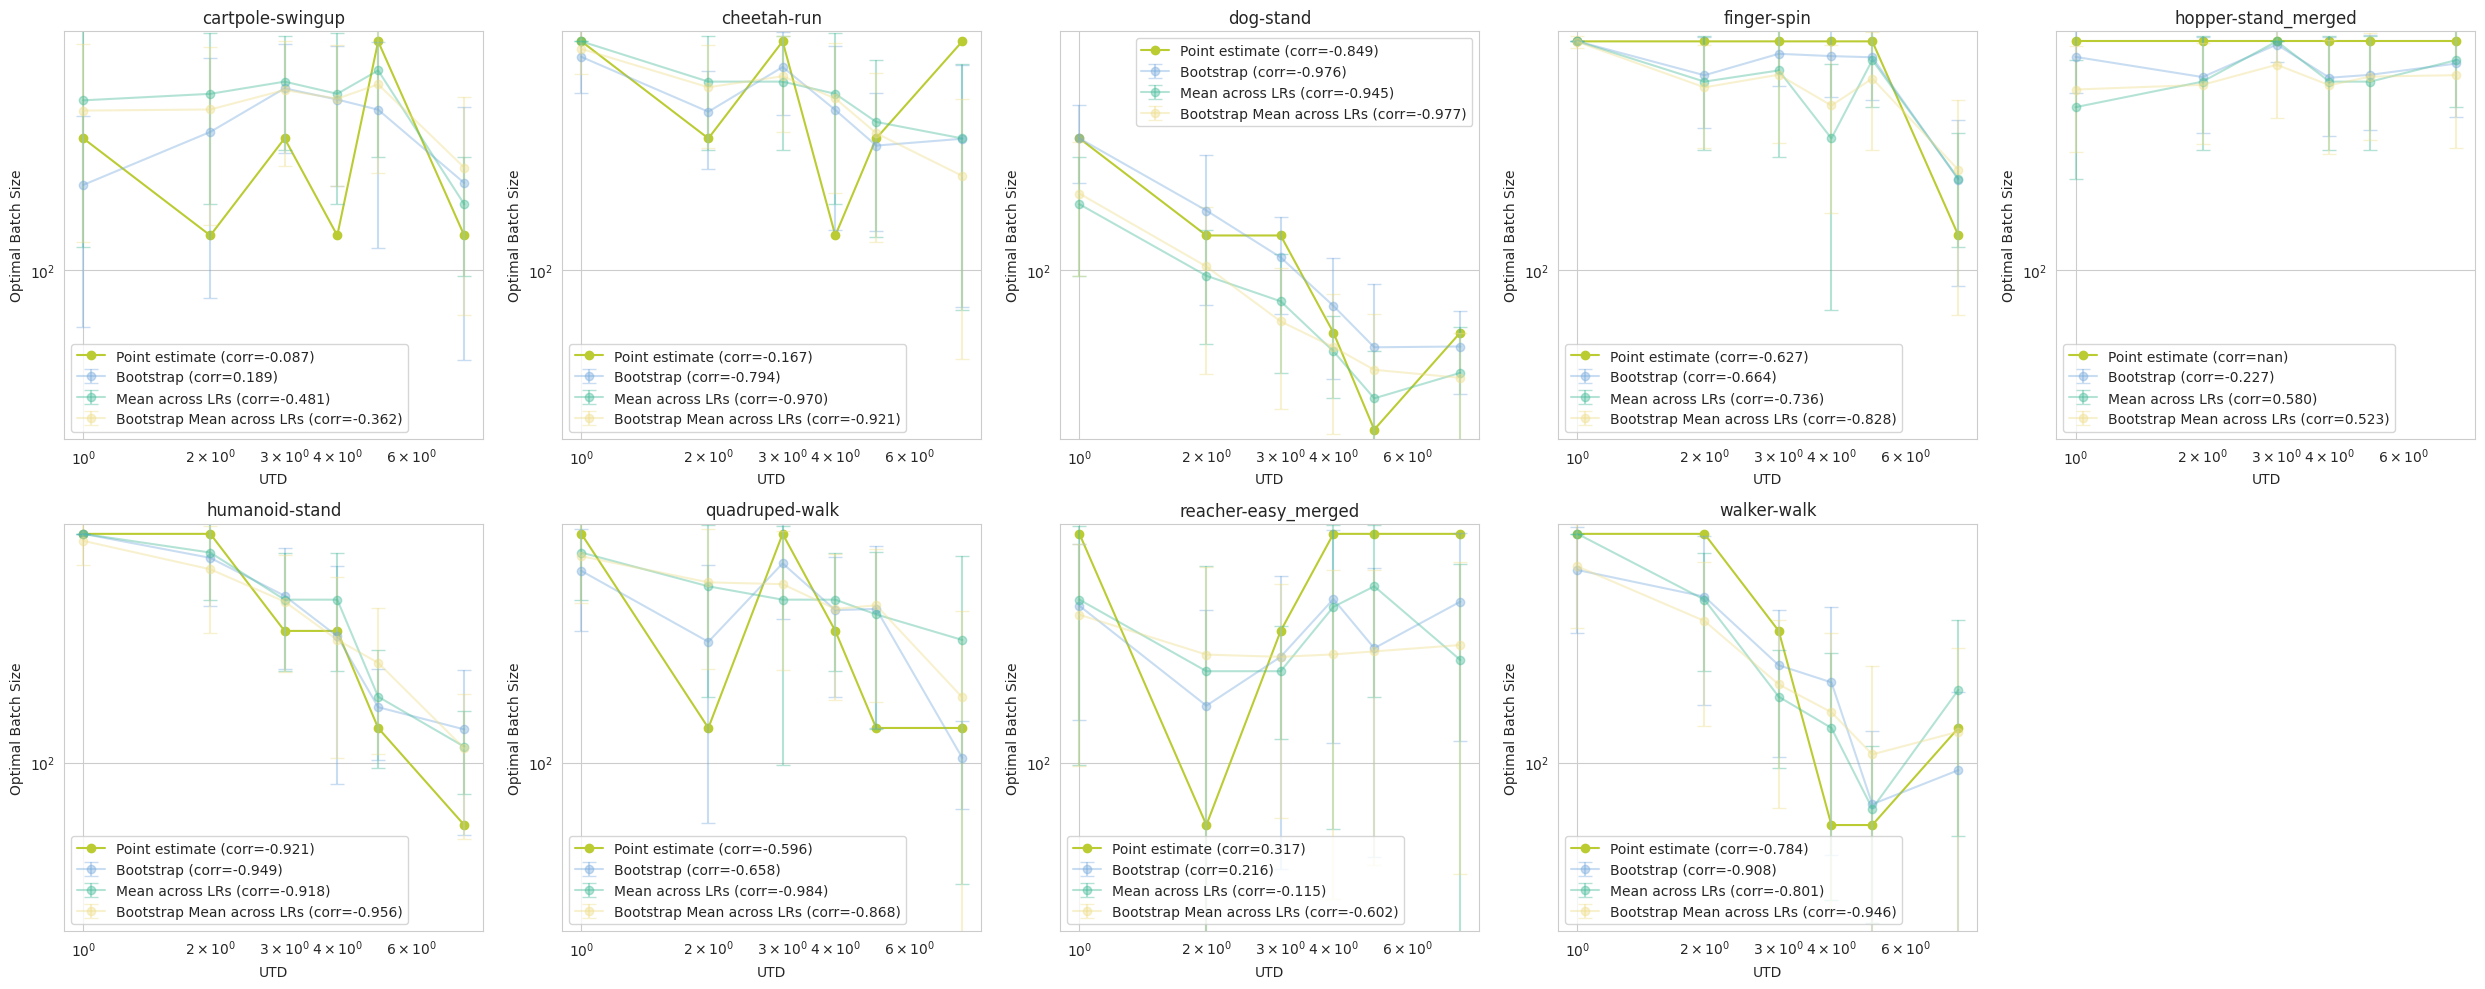

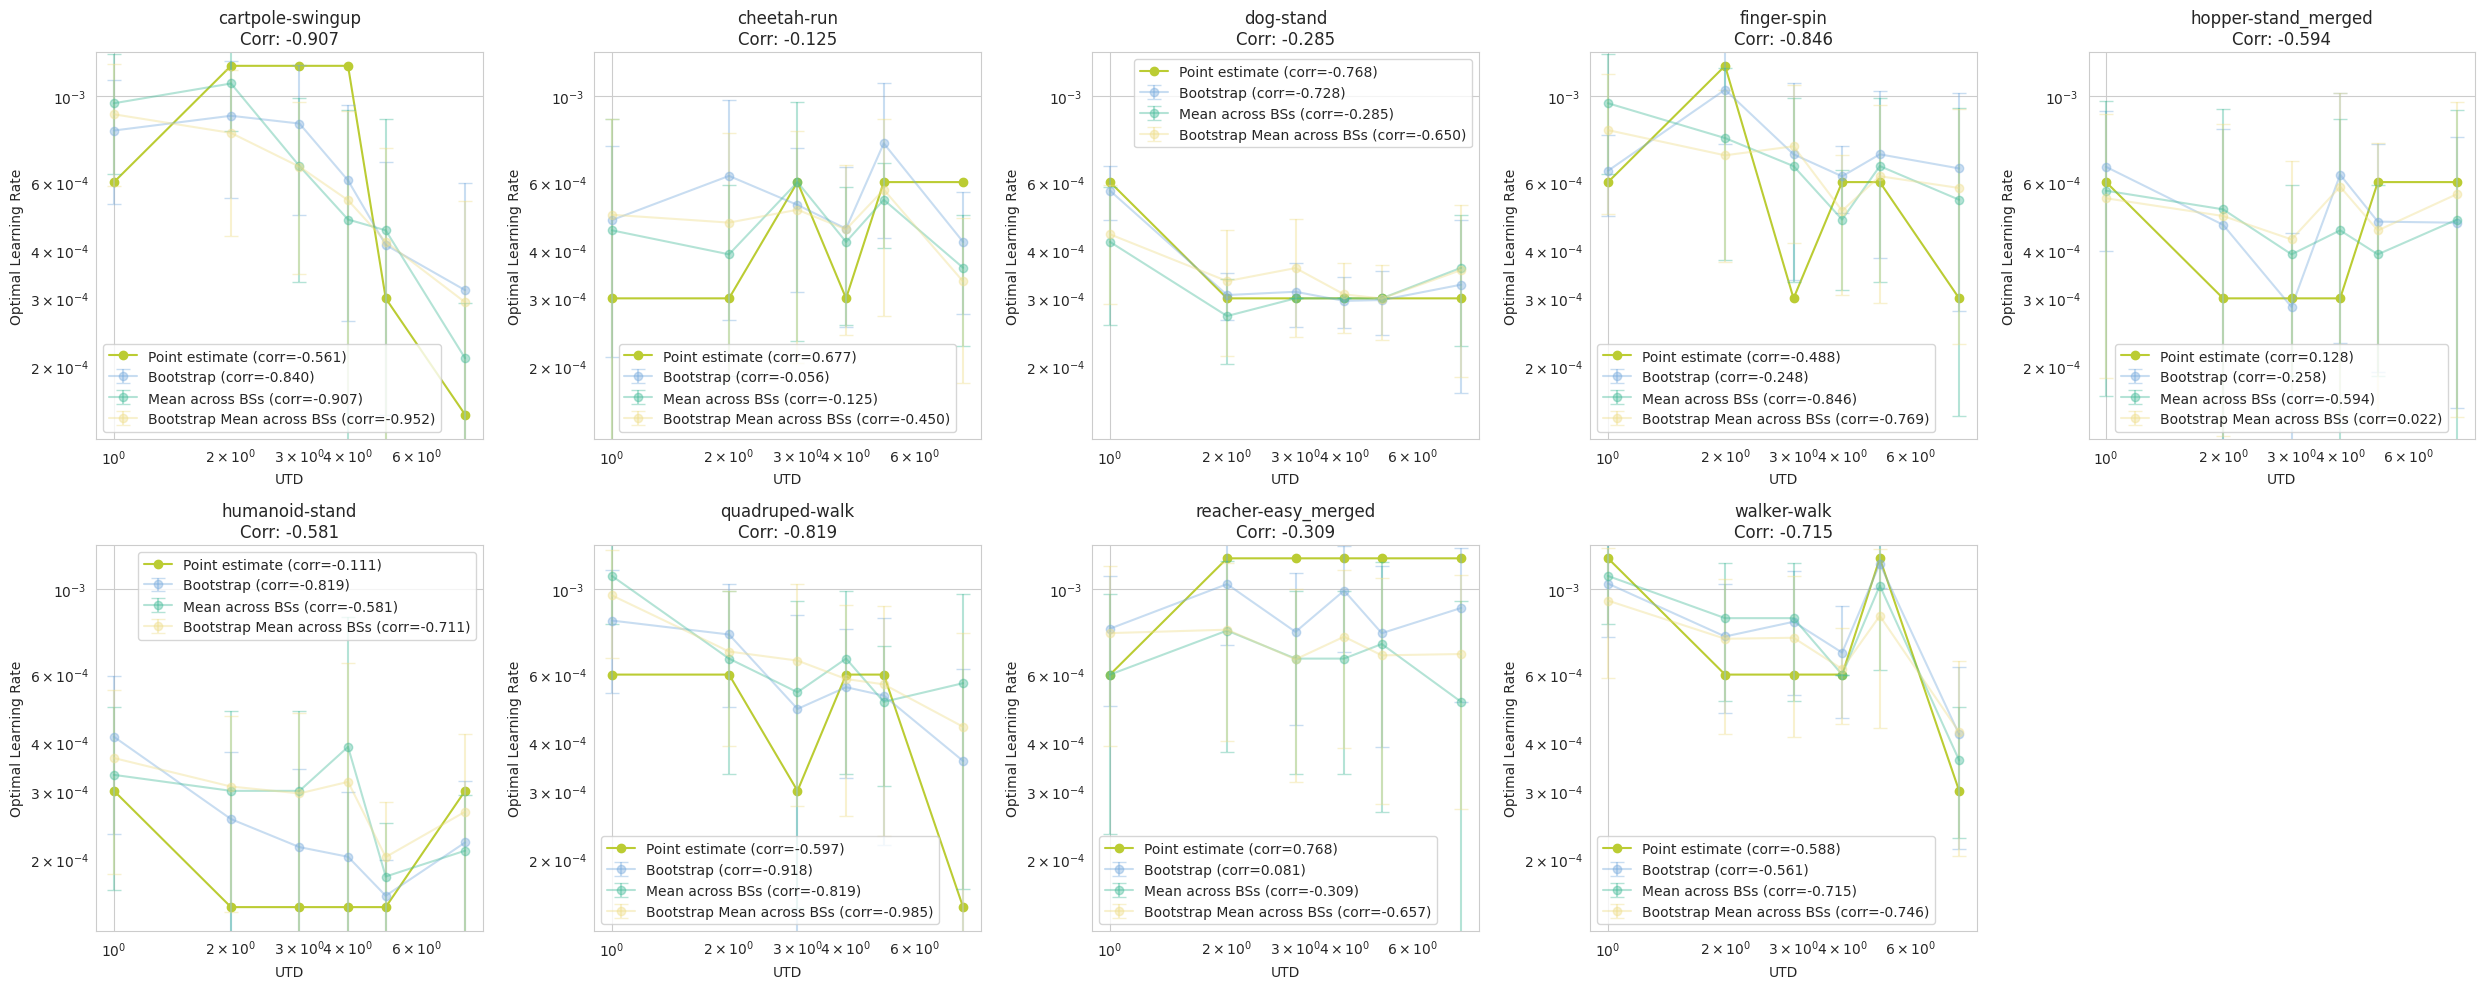

In [43]:
# plot hparams and performance for optimal bs, lr
envs = df_best_lr_bs['env_name'].unique()
n_envs = len(envs)

# Create first figure for batch size plots
n_cols = 5
n_rows = (n_envs + n_cols - 1) // n_cols
fig1, axs1 = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))
axs1 = axs1.flatten()

# Plot 1: Optimal batch size vs UTD with bootstrap CIs and mean optimal batch size
for i, env in enumerate(envs):
    env_data = df_best_lr_bs[df_best_lr_bs['env_name'] == env]
    
    # Calculate correlation for point estimate
    point_bs_corr = np.corrcoef(np.log10(env_data['utd']), np.log10(env_data['best_bs']))[0,1]
    axs1[i].plot(env_data['utd'], env_data['best_bs'], 'o-', label=f'Point estimate (corr={point_bs_corr:.3f})')
    
    # Add bootstrapped confidence intervals
    bootstrap_bs_corr = np.corrcoef(np.log10(env_data['utd']), np.log10(env_data['best_bs_bootstrap_mean']))[0,1]
    axs1[i].errorbar(env_data['utd'], env_data['best_bs_bootstrap_mean'], 
                     yerr=env_data['best_bs_bootstrap_std'],
                     fmt='o-', capsize=5, alpha=0.4,
                     label=f'Bootstrap (corr={bootstrap_bs_corr:.3f})')
    
    # Add mean optimal batch size
    bs_corr = np.corrcoef(np.log10(env_data['utd']), np.log10(env_data['best_bs_lrmean']))[0,1]
    axs1[i].errorbar(env_data['utd'], env_data['best_bs_lrmean'],
                     yerr=env_data['best_bs_lrmean_std'], 
                     fmt='o-', capsize=5, alpha=0.4,
                     label=f'Mean across LRs (corr={bs_corr:.3f})')
    
    # Add mean batch size averaged across learning rates and bootstrap intervals
    bs_corr_all = np.corrcoef(np.log10(env_data['utd']), np.log10(env_data['best_bs_bootstrap_lrmean']))[0,1]
    axs1[i].errorbar(env_data['utd'], env_data['best_bs_bootstrap_lrmean'],
                     yerr=env_data['best_bs_bootstrap_lrmean_std'],
                     fmt='o-', capsize=5, alpha=0.4,
                     label=f'Bootstrap Mean across LRs (corr={bs_corr_all:.3f})')
    
    axs1[i].set_xscale('log')
    axs1[i].set_yscale('log')
    axs1[i].set_xlabel('UTD')
    axs1[i].set_ylim(30, 550)
    axs1[i].set_ylabel('Optimal Batch Size')
    axs1[i].set_title(f'{env}')
    axs1[i].grid(True)
    axs1[i].legend()

# Remove empty subplots from first figure
for j in range(i+1, len(axs1)):
    fig1.delaxes(axs1[j])

plt.tight_layout()
plt.show()

# Create second figure for learning rate plots
fig2, axs2 = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))
axs2 = axs2.flatten()

# Plot 2: Optimal learning rate vs UTD with bootstrap CIs and mean optimal learning rate
for i, env in enumerate(envs):
    env_data = df_best_lr_bs[df_best_lr_bs['env_name'] == env]
    
    # Calculate correlation for point estimate
    point_lr_corr = np.corrcoef(np.log10(env_data['utd']), np.log10(env_data['best_lr']))[0,1]
    axs2[i].plot(env_data['utd'], env_data['best_lr'], 'o-', label=f'Point estimate (corr={point_lr_corr:.3f})')
    
    # Add bootstrapped confidence intervals
    bootstrap_lr_corr = np.corrcoef(np.log10(env_data['utd']), np.log10(env_data['best_lr_bootstrap_mean']))[0,1]
    axs2[i].errorbar(env_data['utd'], env_data['best_lr_bootstrap_mean'],
                     yerr=env_data['best_lr_bootstrap_std'],
                     fmt='o-', capsize=5, alpha=0.4,
                     label=f'Bootstrap (corr={bootstrap_lr_corr:.3f})')
    
    # Add mean optimal learning rate
    lr_corr = np.corrcoef(np.log10(env_data['utd']), np.log10(env_data['best_lr_bsmean']))[0,1]
    axs2[i].errorbar(env_data['utd'], env_data['best_lr_bsmean'],
                     yerr=env_data['best_lr_bsmean_std'],
                     fmt='o-', capsize=5, alpha=0.4,
                     label=f'Mean across BSs (corr={lr_corr:.3f})')
    
    # Add mean learning rate averaged across batch sizes and bootstrap intervals
    lr_corr_all = np.corrcoef(np.log10(env_data['utd']), np.log10(env_data['best_lr_bootstrap_bsmean']))[0,1]
    axs2[i].errorbar(env_data['utd'], env_data['best_lr_bootstrap_bsmean'],
                     yerr=env_data['best_lr_bootstrap_bsmean_std'],
                     fmt='o-', capsize=5, alpha=0.4,
                     label=f'Bootstrap Mean across BSs (corr={lr_corr_all:.3f})')
    
    axs2[i].set_xscale('log')
    axs2[i].set_yscale('log')
    axs2[i].set_xlabel('UTD')
    axs2[i].set_ylim(1.3e-4, 1.3e-3)
    axs2[i].set_ylabel('Optimal Learning Rate')
    axs2[i].set_title(f'{env}\nCorr: {lr_corr:.3f}')
    axs2[i].grid(True)
    axs2[i].legend()

# Remove empty subplots from second figure
for j in range(i+1, len(axs2)):
    fig2.delaxes(axs2[j])

plt.tight_layout()
plt.show()


<AxesSubplot:xlabel='$\\sigma$: UTD ratio', ylabel='$B^*$ Best batch size'>

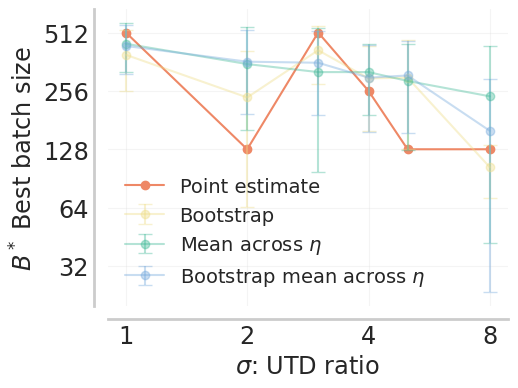

In [140]:
# Plot batch size for quadruped-walk only
env = 'quadruped-walk'
env_data = df_best_lr_bs[df_best_lr_bs['env_name'] == env]

fig, axs = plt.subplots(1, 1)
fig.set_size_inches(496.0/192*2, 369.6/192*2)

# Calculate correlation for point estimate
point_bs_corr = np.corrcoef(np.log10(env_data['utd']), np.log10(env_data['best_bs']))[0,1]
axs.plot(env_data['utd'], env_data['best_bs'], 'o-', 
         #  label=f'Point estimate (corr={point_bs_corr:.3f})')
         color=COLORS[4],
         label=f'Point estimate')

# Add bootstrapped confidence intervals
bootstrap_bs_corr = np.corrcoef(np.log10(env_data['utd']), np.log10(env_data['best_bs_bootstrap_mean']))[0,1]
axs.errorbar(env_data['utd'], env_data['best_bs_bootstrap_mean'],
            yerr=env_data['best_bs_bootstrap_std'],
            fmt='o-', capsize=5, alpha=0.4,
            color=COLORS[3],
            # label=f'Bootstrap (corr={bootstrap_bs_corr:.3f})')
            label=f'Bootstrap')

# Add mean optimal batch size
bs_corr = np.corrcoef(np.log10(env_data['utd']), np.log10(env_data['best_bs_lrmean']))[0,1]
axs.errorbar(env_data['utd'], env_data['best_bs_lrmean'],
            yerr=env_data['best_bs_lrmean_std'],
            fmt='o-', capsize=5, alpha=0.4,
            color=COLORS[2],
            # label=f'Mean across LRs (corr={bs_corr:.3f})')
            label=f'Mean across $\eta$')

# Add mean batch size averaged across learning rates and bootstrap intervals
bs_corr_all = np.corrcoef(np.log10(env_data['utd']), np.log10(env_data['best_bs_bootstrap_lrmean']))[0,1]
axs.errorbar(env_data['utd'], env_data['best_bs_bootstrap_lrmean'],
            yerr=env_data['best_bs_bootstrap_lrmean_std'],
            fmt='o-', capsize=5, alpha=0.4,
            color=COLORS[1],
            # label=f'Bootstrap Mean across LRs (corr={bs_corr_all:.3f})')
            label=f'Bootstrap mean across $\eta$')

axs.set_xscale('log')
axs.set_yscale('log')
axs.legend(prop={'size': 14}, ncol=1, frameon=False)

x = np.logspace(np.log10(1), np.log10(8), num=4)
x_ticks_labels = [f"{x:.0f}" for x in x]
axs.xaxis.set_major_locator(plt.FixedLocator(x))
axs.xaxis.set_minor_locator(plt.NullLocator())
axs.set_xticks(x,x_ticks_labels)

yticks = np.logspace(np.log10(32), np.log10(512), num=5)
ylabels = ["%.0f" % (y) for y in yticks]
axs.yaxis.set_major_locator(plt.FixedLocator(yticks))
axs.yaxis.set_minor_locator(plt.NullLocator())
axs.set_yticks(yticks, ylabels, size=14.5)

plot_utils._annotate_and_decorate_axis(axs, xlabel='$\sigma$: UTD ratio',
                                     ylabel='$B^*$ Best batch size',
                                     labelsize='xx-large', ticklabelsize='xx-large',
                                     grid_alpha=0.2)




## Linear fit

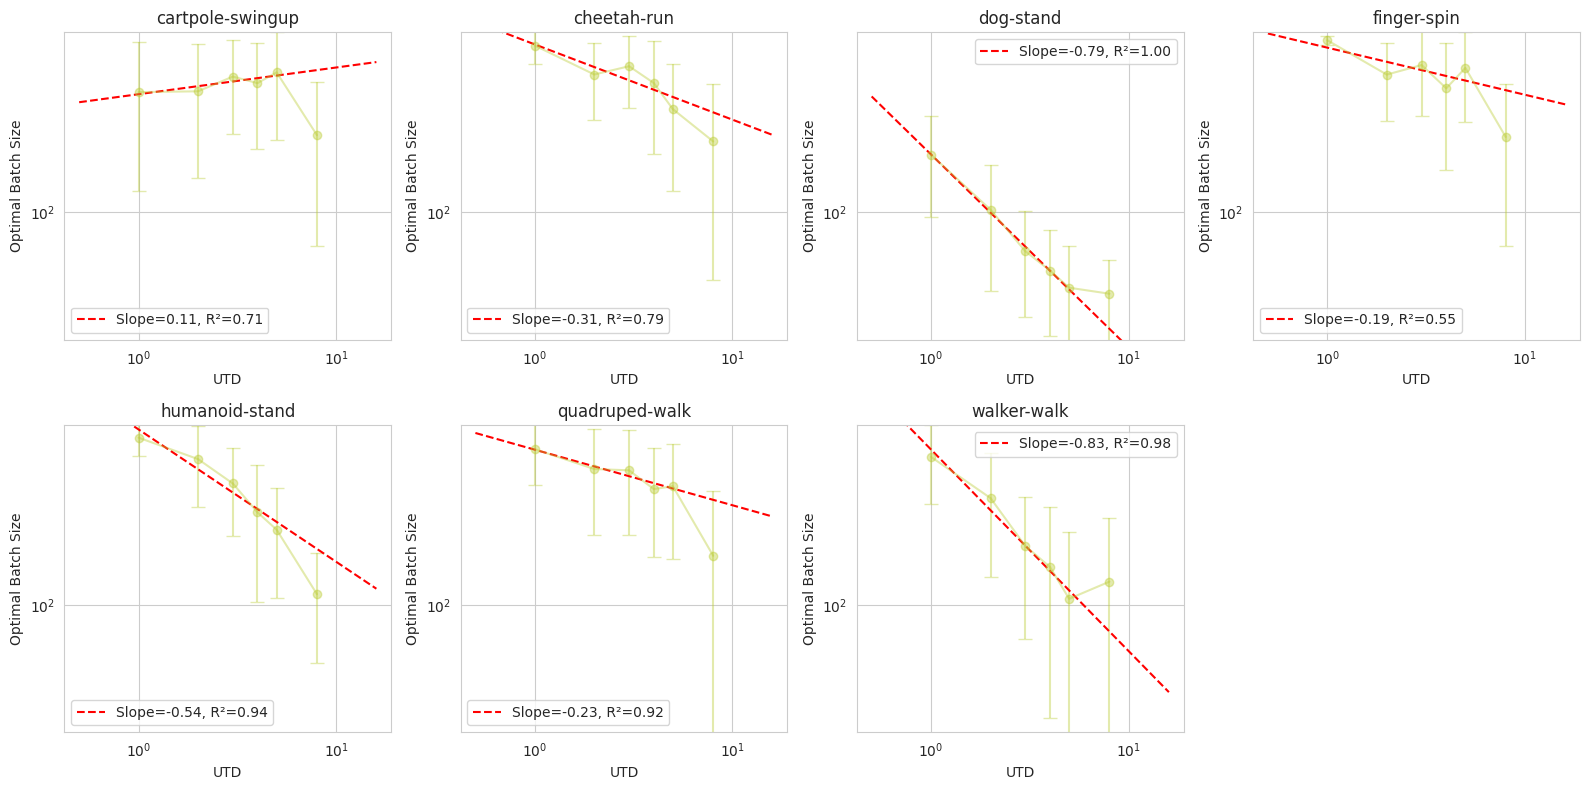

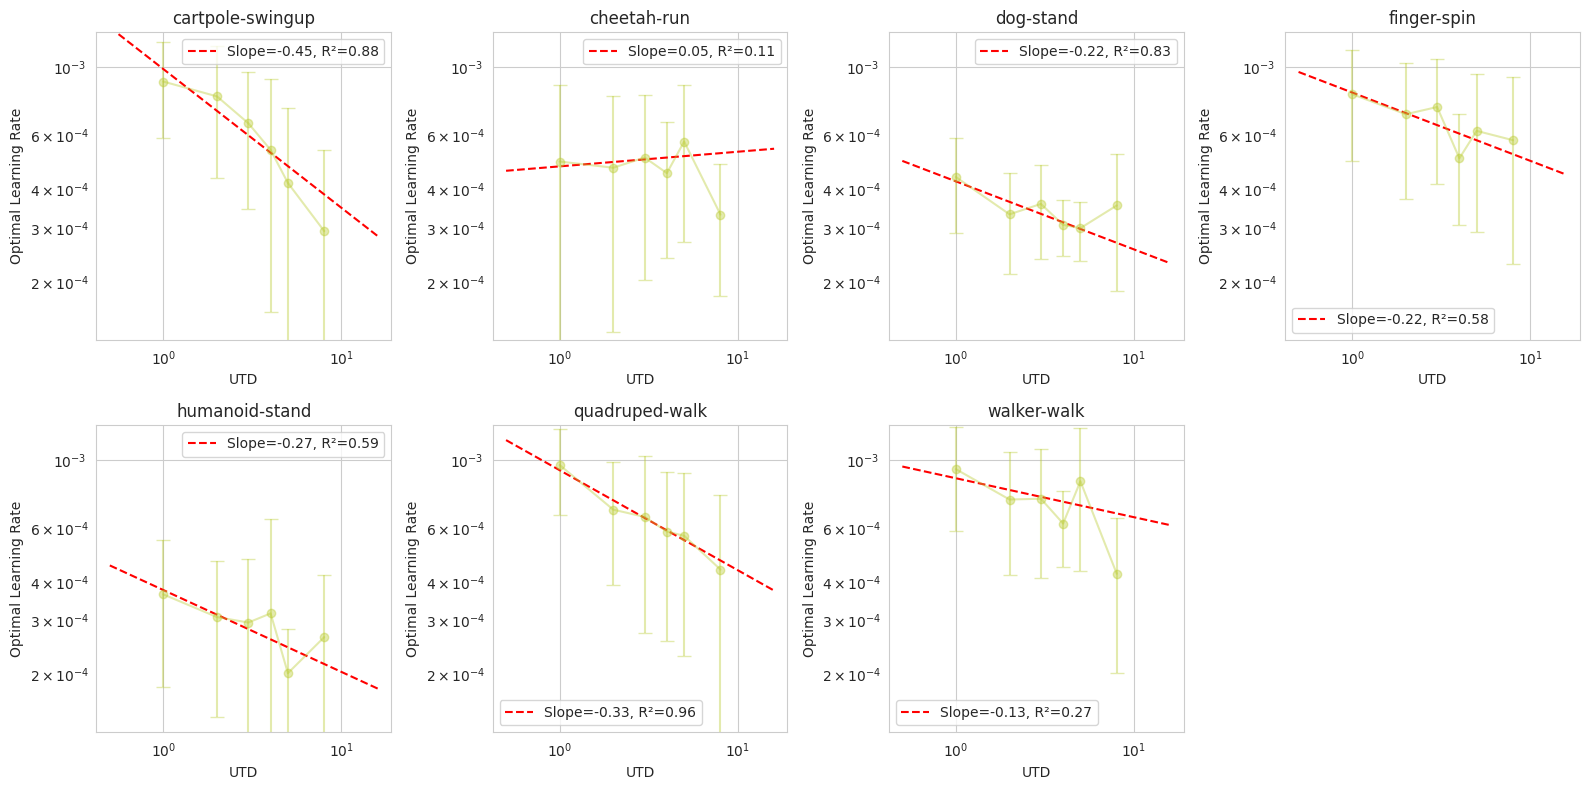

In [44]:
# Make linear fit for bs and lr
from sklearn.linear_model import LinearRegression

envs = df_best_lr_bs['env_name'].unique()
envs = [x for x in envs if 'merged' not in x]
n_envs = len(envs)

# Create first figure for batch size plots
n_cols = 4
n_rows = (n_envs + n_cols - 1) // n_cols
fig1, axs1 = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
axs1 = axs1.flatten()

# Plot 1: Optimal batch size vs UTD with bootstrap CIs and mean optimal batch size
for i, env in enumerate(envs):
    env_data = df_best_lr_bs[df_best_lr_bs['env_name'] == env]
    
    bs_corr_all = np.corrcoef(np.log10(env_data['utd']), np.log10(env_data['best_bs_bootstrap_lrmean']))[0,1]
    axs1[i].errorbar(env_data['utd'], env_data['best_bs_bootstrap_lrmean'],
                     yerr=env_data['best_bs_bootstrap_lrmean_std'],
                     fmt='o-', capsize=5, alpha=0.4,)
    
    # Fit linear regression in log-log space
    # X = np.log10(env_data['utd'].values).reshape(-1, 1)
    # y = np.log10(env_data['best_bs_bootstrap_lrmean'].values)
    X = np.log10(env_data['utd'].values[:-1]).reshape(-1, 1)
    y = np.log10(env_data['best_bs_bootstrap_lrmean'].values[:-1])
    reg = LinearRegression().fit(X, y)
    
    # Plot the fit line
    x_fit = np.array([min(env_data['utd'])*0.5, max(env_data['utd'])*2])
    y_fit = 10**(reg.predict(np.log10(x_fit).reshape(-1,1)))
    axs1[i].plot(x_fit, y_fit, '--', color='red', 
                 label=f'Slope={reg.coef_[0]:.2f}, R²={reg.score(X,y):.2f}')
    
    axs1[i].set_xscale('log')
    axs1[i].set_yscale('log')
    axs1[i].set_xlabel('UTD')
    axs1[i].set_ylim(30, 550)
    axs1[i].set_ylabel('Optimal Batch Size')
    axs1[i].set_title(f'{env}')
    axs1[i].grid(True)
    axs1[i].legend()

# Remove empty subplots from first figure
for j in range(i+1, len(axs1)):
    fig1.delaxes(axs1[j])

plt.tight_layout()
plt.show()

# Create second figure for learning rate plots
fig2, axs2 = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
axs2 = axs2.flatten()

# Plot 2: Optimal learning rate vs UTD with bootstrap CIs and mean optimal learning rate
for i, env in enumerate(envs):
    env_data = df_best_lr_bs[df_best_lr_bs['env_name'] == env]

    lr_corr_all = np.corrcoef(np.log10(env_data['utd']), np.log10(env_data['best_lr_bootstrap_bsmean']))[0,1]
    axs2[i].errorbar(env_data['utd'], env_data['best_lr_bootstrap_bsmean'],
                     yerr=env_data['best_lr_bootstrap_bsmean_std'],
                     fmt='o-', capsize=5, alpha=0.4,)
    
    # Fit linear regression in log-log space
    # X = np.log10(env_data['utd'].values).reshape(-1, 1)
    # y = np.log10(env_data['best_lr_bootstrap_bsmean'].values)
    X = np.log10(env_data['utd'].values[:-1]).reshape(-1, 1)
    y = np.log10(env_data['best_lr_bootstrap_bsmean'].values[:-1])
    reg = LinearRegression().fit(X, y)
    
    # Plot the fit line
    x_fit = np.array([min(env_data['utd'])*0.5, max(env_data['utd'])*2])
    y_fit = 10**(reg.predict(np.log10(x_fit).reshape(-1,1)))
    axs2[i].plot(x_fit, y_fit, '--', color='red', 
                 label=f'Slope={reg.coef_[0]:.2f}, R²={reg.score(X,y):.2f}')
    
    axs2[i].set_xscale('log')
    axs2[i].set_yscale('log')
    axs2[i].set_xlabel('UTD')
    axs2[i].set_ylim(1.3e-4, 1.3e-3)
    axs2[i].set_ylabel('Optimal Learning Rate')
    axs2[i].set_title(f'{env}')
    axs2[i].grid(True)
    axs2[i].legend()

# Remove empty subplots from second figure
for j in range(i+1, len(axs2)):
    fig2.delaxes(axs2[j])

plt.tight_layout()
plt.show()


In [45]:
# Linear fit with shared slope across environments
from sklearn.metrics import r2_score  

def fit_shared_slope_regression(df, envs, x_col='utd', y_col='best_lr_bootstrap_bsmean'):
    # Get data for all environments
    X_all = []
    y_all = []
    env_indices = []

    for i, env in enumerate(envs):
        env_data = df[df['env_name'] == env]    
        X_all.append(np.log10(env_data[x_col].values[:]))
        y_all.append(np.log10(env_data[y_col].values[:]))
        env_indices.extend([i] * len(env_data))
        
    X_all = np.concatenate(X_all).reshape(-1, 1)
    y_all = np.concatenate(y_all)
    env_indices = np.array(env_indices)

    # Create dummy variables for environment intercepts
    n_envs = len(envs)
    env_dummies = np.zeros((len(X_all), n_envs))
    for i in range(n_envs):
        env_dummies[env_indices == i, i] = 1

    # Combine UTD and environment dummies
    X_combined = np.hstack([X_all, env_dummies[:, 1:]])  # Drop first dummy to avoid collinearity

    # Fit regression
    reg_shared = LinearRegression(fit_intercept=True).fit(X_combined, y_all)

    # Extract shared slope and environment-specific intercepts
    shared_slope = reg_shared.coef_[0]
    env_intercepts = np.zeros(n_envs)
    env_intercepts[0] = reg_shared.intercept_
    env_intercepts[1:] = reg_shared.intercept_ + reg_shared.coef_[1:]
    
    return reg_shared, X_all, y_all, env_indices, n_envs


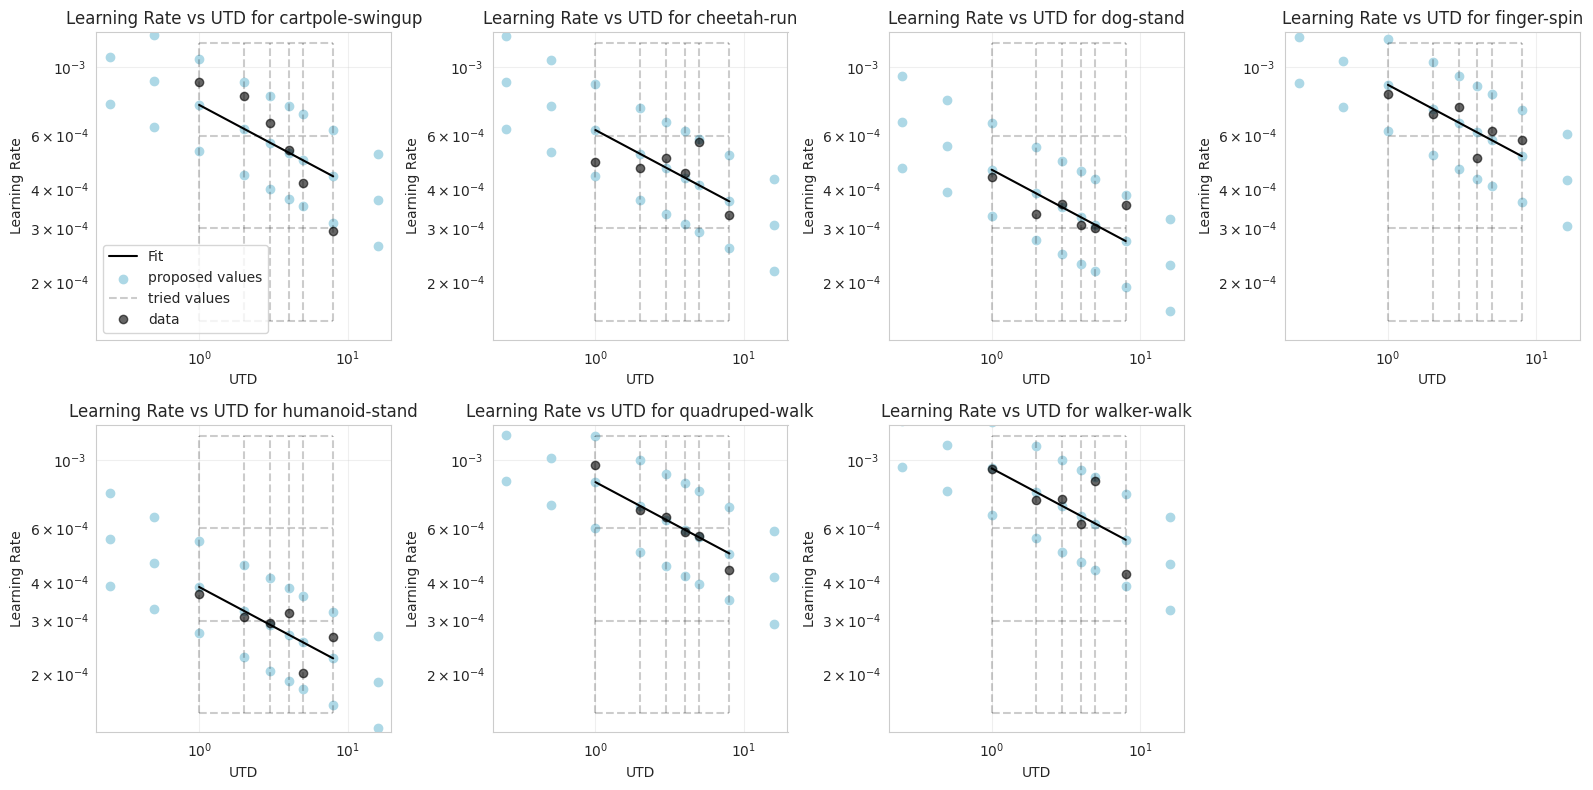

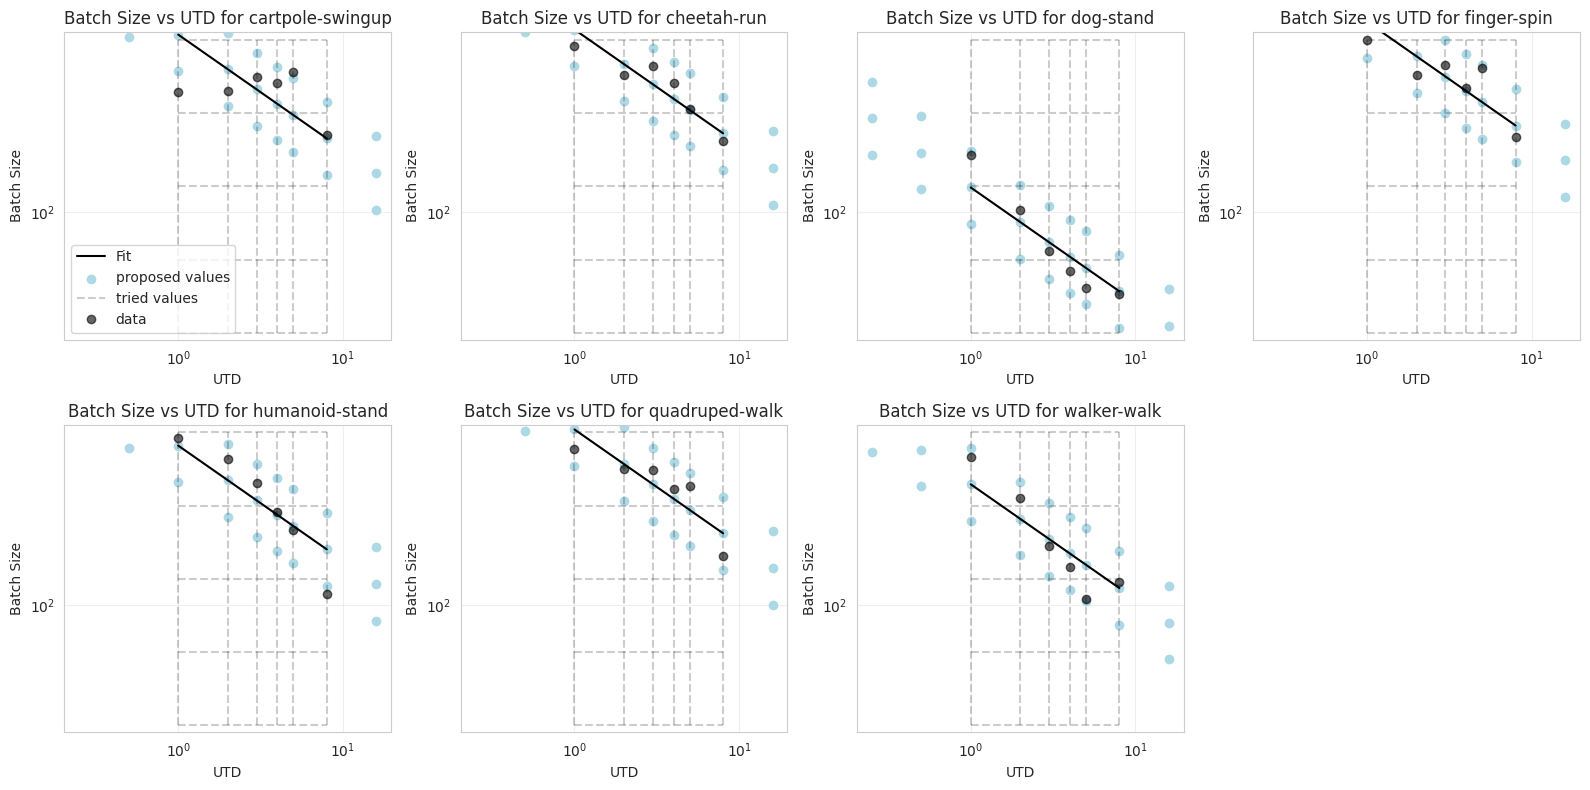

In [46]:
# Plot separate plots for each environment
reg_shared, X_all, y_all, env_indices, n_envs = fit_shared_slope_regression(df_best_lr_bs, envs)

# Create figures
n_cols = 4
n_rows = (n_envs + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
axes = axes.flatten()

# Create table to store proposed values
proposed_values = {'Environment': [], 'UTD': [], 'Learning Rate': [], 'Learning Rate x√2': [], 'Learning Rate x√0.5': []}

for i, env in enumerate(envs):
    # Get predictions
    X_plot = np.linspace(X_all.min(), X_all.max(), 100).reshape(-1, 1)
    env_dummies_plot = np.zeros((len(X_plot), n_envs-1))
    if i > 0:
        env_dummies_plot[:, i-1] = 1
    X_combined_plot = np.hstack([X_plot, env_dummies_plot])
    y_plot = reg_shared.predict(X_combined_plot)
    
    # Plot regression line
    axes[i].plot(10**X_plot, 10**y_plot, '-', color='black',
                label=f'Fit')
    
    # Plot data points for this environment
    mask = env_indices == i
    axes[i].errorbar(10**X_all[mask], 10**y_all[mask], 
                    yerr=None,
                    fmt='o', capsize=5, alpha=0.6, label='data', color='black')
    
    # Get unique UTD values for this environment
    mask = env_indices == i
    utds = np.array([0.25, 0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 8.0, 16.0])  # Include 0.5 and 16
    X_utds = np.log10(utds).reshape(-1,1)
    env_dummies_utds = np.zeros((len(X_utds), n_envs-1))
    if i > 0:
        env_dummies_utds[:, i-1] = 1
    X_combined_utds = np.hstack([X_utds, env_dummies_utds])
    predictions = 10**reg_shared.predict(X_combined_utds)
    
    # Store values in table
    for utd, pred in zip(utds, predictions):
        proposed_values['Environment'].append(env)
        proposed_values['UTD'].append(f"{utd:.2f}")
        proposed_values['Learning Rate'].append(f"{pred:.2e}")
        proposed_values['Learning Rate x√2'].append(f"{pred * np.sqrt(2):.2e}")
        proposed_values['Learning Rate x√0.5'].append(f"{pred * np.sqrt(0.5):.2e}")
    
    # Plot x2 and x0.5 lines for each UTD point
    axes[i].scatter(utds, predictions * np.sqrt(2), marker='o', color='lightblue', alpha=1, label='proposed values')
    axes[i].scatter(utds, predictions * np.sqrt(0.5), marker='o', color='lightblue', alpha=1)
    axes[i].scatter(utds, predictions, marker='o', color='lightblue', alpha=1)
    
    # plot possible values of learning rate as lines
    utd_values = df[df['env_name'] == env]['utd'].unique()
    lr_values = df['learning_rate'].unique()
    # Plot vertical lines for UTD values
    for utd in utd_values:
        axes[i].plot([utd, utd], [min(lr_values), max(lr_values)], 
                    color='black', alpha=0.2, linestyle='--',
                    label='tried values' if utd == utd_values[0] else None)
    # Plot horizontal lines for learning rate values
    for lr in lr_values:
        axes[i].plot([min(utd_values), max(utd_values)], [lr, lr],  
                    color='black', alpha=0.2, linestyle='--')
    
    axes[i].set_xlabel('UTD')
    axes[i].set_ylabel('Learning Rate')
    axes[i].set_ylim(1.3e-4, 1.3e-3)
    axes[i].set_title(f'Learning Rate vs UTD for {env}')
    if i == 0:
        axes[i].legend()
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xscale('log')
    axes[i].set_yscale('log')

# Create a single legend for all plots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

# Plot separate plots for batch size
reg_shared, X_all, y_all, env_indices, n_envs = fit_shared_slope_regression(df_best_lr_bs, envs, y_col='best_bs_bootstrap_lrmean')

# Create figures 
n_cols = 4
n_rows = (n_envs + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
axes = axes.flatten()

# Create table to store proposed batch size values
proposed_bs_values = {'Environment': [], 'UTD': [], 'Batch Size': [], 'Batch Size x√2': [], 'Batch Size x√0.5': []}

for i, env in enumerate(envs):
    # Plot data points for this environment
    mask = env_indices == i
    axes[i].errorbar(10**X_all[mask], 10**y_all[mask],
                    yerr=None, 
                    fmt='o', capsize=5, alpha=0.6, label='data', color='black')
    
    # Create dummy variables for this environment
    X_plot = np.linspace(X_all.min(), X_all.max(), 100).reshape(-1, 1)
    env_dummies_plot = np.zeros((len(X_plot), n_envs-1))
    if i > 0:
        env_dummies_plot[:, i-1] = 1
        
    # Combine with X values and get predictions
    X_combined_plot = np.hstack([X_plot, env_dummies_plot])
    y_plot = reg_shared.predict(X_combined_plot)
    
    # Plot regression line
    axes[i].plot(10**X_plot, 10**y_plot, '-', color='black',
                label=f'Fit')
    
    # Get predictions for specific UTD values
    utds = np.array([0.25, 0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 8.0, 16.0])  # Include 0.5 and 16
    X_utds = np.log10(utds).reshape(-1,1)
    env_dummies_utds = np.zeros((len(X_utds), n_envs-1))
    if i > 0:
        env_dummies_utds[:, i-1] = 1
    X_combined_utds = np.hstack([X_utds, env_dummies_utds])
    predictions = 10**reg_shared.predict(X_combined_utds)
    
    # Store values in table
    for utd, pred in zip(utds, predictions):
        proposed_bs_values['Environment'].append(env)
        proposed_bs_values['UTD'].append(f"{utd:.2f}")
        proposed_bs_values['Batch Size'].append(f"{pred:.0f}")
        proposed_bs_values['Batch Size x√2'].append(f"{pred * np.sqrt(2):.0f}")
        proposed_bs_values['Batch Size x√0.5'].append(f"{pred * np.sqrt(0.5):.0f}")
    
    # Plot x2 and x0.5 lines for each UTD point
    axes[i].scatter(utds, predictions * np.sqrt(2), marker='o', color='lightblue', alpha=1, label='proposed values')
    axes[i].scatter(utds, predictions * np.sqrt(0.5), marker='o', color='lightblue', alpha=1)
    axes[i].scatter(utds, predictions, marker='o', color='lightblue', alpha=1)
    
    # plot possible values of batch size as lines
    utd_values = df[df['env_name'] == env]['utd'].unique()
    bs_values = df['batch_size'].unique()
    # Plot vertical lines for UTD values
    for utd in utd_values:
        axes[i].plot([utd, utd], [min(bs_values), max(bs_values)], 
                    color='black', alpha=0.2, linestyle='--',
                    label='tried values' if utd == utd_values[0] else None)
    # Plot horizontal lines for batch size values
    for bs in bs_values:
        axes[i].plot([min(utd_values), max(utd_values)], [bs, bs],  
                    color='black', alpha=0.2, linestyle='--')
    
    axes[i].set_xlabel('UTD')
    axes[i].set_ylabel('Batch Size')
    axes[i].set_ylim(30, 550)
    axes[i].set_title(f'Batch Size vs UTD for {env}')
    if i == 0:
        axes[i].legend()
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xscale('log')
    axes[i].set_yscale('log')

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


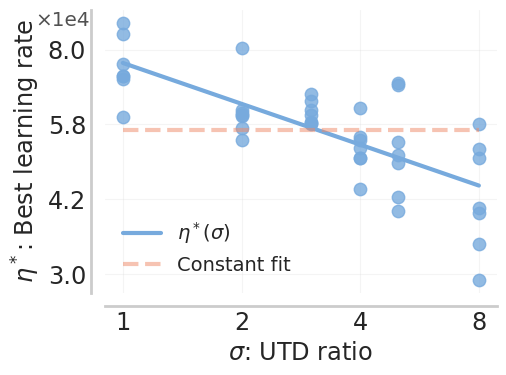

In [111]:
# Plot all environments in one plot
reg_shared, X_all, y_all, env_indices, n_envs = fit_shared_slope_regression(df_best_lr_bs, envs)

fig, ax = plt.subplots(1, 1)
fig.set_size_inches(496.0/192*2, 369.6/192*2)

# Get the slope coefficient (shared across environments)
slope = reg_shared.coef_[0]

for i, (env, color) in enumerate(zip(envs, colors)):
    # Get predictions
    X_plot = np.linspace(X_all.min(), X_all.max(), 100).reshape(-1, 1)
    env_dummies_plot = np.zeros((len(X_plot), n_envs-1))
    if i > 0:
        env_dummies_plot[:, i-1] = 1
    X_combined_plot = np.hstack([X_plot, env_dummies_plot])
    y_plot = reg_shared.predict(X_combined_plot)
    
    # Get intercept for this environment
    if i == 0:
        intercept = reg_shared.intercept_
    else:
        intercept = reg_shared.intercept_ + reg_shared.coef_[i]
    shift = intercept - reg_shared.intercept_
        
    # Plot data points for this environment
    mask = env_indices == i
    plt.scatter(10**X_all[mask], 10**(y_all[mask] - shift), 
               marker='o', color=COLORS[1], alpha=0.8, s=80)

# Plot regression line using slope and intercept directly
y_plot_direct = slope * X_plot + intercept - shift
plt.plot(10**X_plot, 10**y_plot_direct.flatten(), color=COLORS[1], linewidth=3, label='$\eta^*(\sigma)$')

# Fit separate regression for each environment
r2_scores = []
for i, env in enumerate(envs):
    # Get data for this environment
    mask = env_indices == i
    X_env = X_all[mask].reshape(-1,1)
    y_env = y_all[mask]
    
    # Calculate mean for constant fit
    y_mean = np.mean(y_env)
    
    # Get predictions (constant line at mean)
    X_plot = np.linspace(X_all.min(), X_all.max(), 100).reshape(-1, 1)
    # Get intercept for this environment
    if i == 0:
        shift = 0
    else:
        shift = reg_shared.coef_[i]
    y_plot = np.full_like(X_plot, y_mean - shift)
    
    # Plot constant line
plt.plot(10**X_plot, 10**y_plot.flatten(), '--', color=COLORS[4], alpha=0.5, label='Constant fit', linewidth=3)

plt.xscale('log')
plt.yscale('log')
ax.legend(prop={'size': 14}, ncol=1, frameon=False)

x = np.logspace(np.log10(1), np.log10(8), num=4)
x_ticks_labels = [f"{x:.0f}" for x in x]
ax.xaxis.set_major_locator(plt.FixedLocator(x))
ax.xaxis.set_minor_locator(plt.NullLocator())
ax.set_xticks(x,x_ticks_labels)

yticks = np.logspace(np.log10(3e-4), np.log10(8e-4), num=4)
ylabels = ["%.1f" % (y*1e4) for y in yticks]
ax.yaxis.set_major_locator(plt.FixedLocator(yticks))
ax.yaxis.set_minor_locator(plt.NullLocator())
ax.set_yticks(yticks, ylabels, size=14.5)

plot_utils._annotate_and_decorate_axis(ax, xlabel='$\sigma$: UTD ratio',
                                     ylabel='$\eta^*$: Best learning rate',
                                     labelsize='xx-large', ticklabelsize='xx-large',
                                     grid_alpha=0.2, legend=False)

plt.text(-0.04, 0.93, '×1e4', transform=ax.transAxes,
         horizontalalignment='right', verticalalignment='bottom',
         fontsize='x-large', alpha=0.8)

plt.tight_layout()
plt.show()


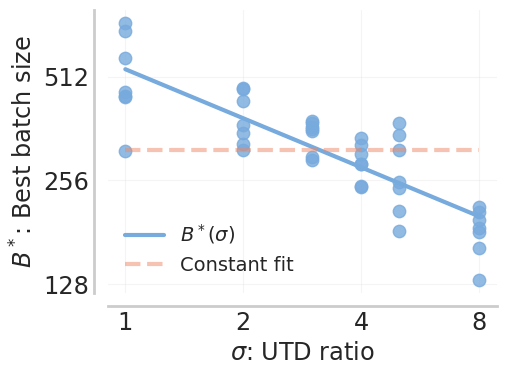

In [116]:
# Plot all environments in one plot
reg_shared, X_all, y_all, env_indices, n_envs = fit_shared_slope_regression(df_best_lr_bs, envs, y_col='best_bs_bootstrap_lrmean')

fig, ax = plt.subplots(1, 1)
fig.set_size_inches(496.0/192*2, 369.6/192*2)

# Get the slope coefficient (shared across environments)
slope = reg_shared.coef_[0]

for i, (env, color) in enumerate(zip(envs, colors)):
    # Get predictions
    X_plot = np.linspace(X_all.min(), X_all.max(), 100).reshape(-1, 1)
    env_dummies_plot = np.zeros((len(X_plot), n_envs-1))
    if i > 0:
        env_dummies_plot[:, i-1] = 1
    X_combined_plot = np.hstack([X_plot, env_dummies_plot])
    y_plot = reg_shared.predict(X_combined_plot)
    
    # Get intercept for this environment
    if i == 0:
        intercept = reg_shared.intercept_
    else:
        intercept = reg_shared.intercept_ + reg_shared.coef_[i]
    shift = intercept - reg_shared.intercept_
        
    # Plot data points for this environment
    mask = env_indices == i
    plt.scatter(10**X_all[mask], 10**(y_all[mask] - shift), 
               marker='o', color=COLORS[1], alpha=0.8, s=80)

# Plot regression line using slope and intercept directly
y_plot_direct = slope * X_plot + intercept - shift
plt.plot(10**X_plot, 10**y_plot_direct.flatten(), color=COLORS[1], linewidth=3, label='$B^*(\sigma)$')

# Fit separate regression for each environment
r2_scores = []
for i, env in enumerate(envs):
    # Get data for this environment
    mask = env_indices == i
    X_env = X_all[mask].reshape(-1,1)
    y_env = y_all[mask]
    
    # Calculate mean for constant fit
    y_mean = np.mean(y_env)
    
    # Get predictions (constant line at mean)
    X_plot = np.linspace(X_all.min(), X_all.max(), 100).reshape(-1, 1)
    # Get intercept for this environment
    if i == 0:
        shift = 0
    else:
        shift = reg_shared.coef_[i]
    y_plot = np.full_like(X_plot, y_mean - shift)
    
    # Plot constant line
plt.plot(10**X_plot, 10**y_plot.flatten(), '--', color=COLORS[4], alpha=0.5, label='Constant fit', linewidth=3)

plt.xscale('log')
plt.yscale('log')
ax.legend(prop={'size': 14}, ncol=1, frameon=False, loc='lower left')

x = np.logspace(np.log10(1), np.log10(8), num=4)
x_ticks_labels = [f"{x:.0f}" for x in x]
ax.xaxis.set_major_locator(plt.FixedLocator(x))
ax.xaxis.set_minor_locator(plt.NullLocator())
ax.set_xticks(x,x_ticks_labels)

yticks = np.logspace(np.log10(128), np.log10(512), num=3)
ylabels = ["%.0f" % (y) for y in yticks]
ax.yaxis.set_major_locator(plt.FixedLocator(yticks))
ax.yaxis.set_minor_locator(plt.NullLocator())
ax.set_yticks(yticks, ylabels, size=14.5)

plot_utils._annotate_and_decorate_axis(ax, xlabel='$\sigma$: UTD ratio',
                                     ylabel='$B^*$: Best batch size',
                                     labelsize='xx-large', ticklabelsize='xx-large',
                                     grid_alpha=0.2, legend=False)

# plt.text(1.04, -0.14, '×1e4', transform=ax.transAxes,
#          horizontalalignment='right', verticalalignment='bottom',
#          fontsize='x-large', alpha=0.8)
# plt.text(-0.04, 0.93, '×1e7', transform=ax.transAxes,
#          horizontalalignment='right', verticalalignment='bottom',
#          fontsize='x-large', alpha=0.8)

plt.tight_layout()
plt.show()


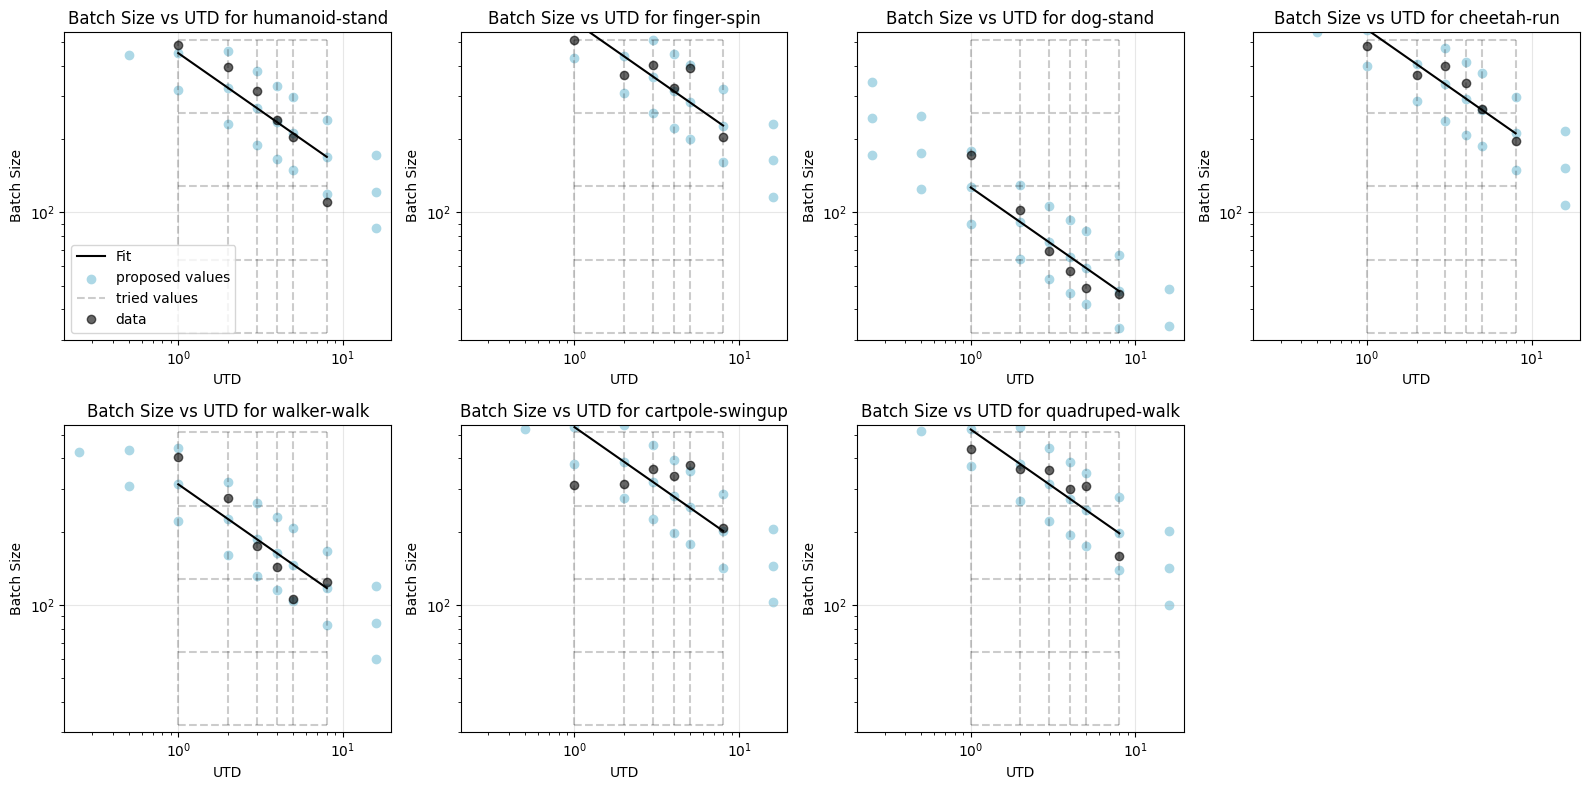

In [46]:

# Plot separate plots for batch size
reg_shared, X_all, y_all, env_indices, n_envs = fit_shared_slope_regression(df_best_lr_bs, envs, y_col='best_bs_bootstrap_lrmean')

# Create figures 
n_cols = 4
n_rows = (n_envs + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
axes = axes.flatten()

# Create table to store proposed batch size values
proposed_bs_values = {'Environment': [], 'UTD': [], 'Batch Size': [], 'Batch Size x√2': [], 'Batch Size x√0.5': []}

for i, env in enumerate(envs):
    # Plot data points for this environment
    mask = env_indices == i
    axes[i].errorbar(10**X_all[mask], 10**y_all[mask],
                    yerr=None, 
                    fmt='o', capsize=5, alpha=0.6, label='data', color='black')
    
    # Create dummy variables for this environment
    X_plot = np.linspace(X_all.min(), X_all.max(), 100).reshape(-1, 1)
    env_dummies_plot = np.zeros((len(X_plot), n_envs-1))
    if i > 0:
        env_dummies_plot[:, i-1] = 1
        
    # Combine with X values and get predictions
    X_combined_plot = np.hstack([X_plot, env_dummies_plot])
    y_plot = reg_shared.predict(X_combined_plot)
    
    # Plot regression line
    axes[i].plot(10**X_plot, 10**y_plot, '-', color='black',
                label=f'Fit')
    
    # Get predictions for specific UTD values
    utds = np.array([0.25, 0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 8.0, 16.0])  # Include 0.5 and 16
    X_utds = np.log10(utds).reshape(-1,1)
    env_dummies_utds = np.zeros((len(X_utds), n_envs-1))
    if i > 0:
        env_dummies_utds[:, i-1] = 1
    X_combined_utds = np.hstack([X_utds, env_dummies_utds])
    predictions = 10**reg_shared.predict(X_combined_utds)
    
    # Store values in table
    for utd, pred in zip(utds, predictions):
        proposed_bs_values['Environment'].append(env)
        proposed_bs_values['UTD'].append(f"{utd:.2f}")
        proposed_bs_values['Batch Size'].append(f"{pred:.0f}")
        proposed_bs_values['Batch Size x√2'].append(f"{pred * np.sqrt(2):.0f}")
        proposed_bs_values['Batch Size x√0.5'].append(f"{pred * np.sqrt(0.5):.0f}")
    
    # Plot x2 and x0.5 lines for each UTD point
    axes[i].scatter(utds, predictions * np.sqrt(2), marker='o', color='lightblue', alpha=1, label='proposed values')
    axes[i].scatter(utds, predictions * np.sqrt(0.5), marker='o', color='lightblue', alpha=1)
    axes[i].scatter(utds, predictions, marker='o', color='lightblue', alpha=1)
    
    # plot possible values of batch size as lines
    utd_values = df[df['env_name'] == env]['utd'].unique()
    bs_values = df['batch_size'].unique()
    # Plot vertical lines for UTD values
    for utd in utd_values:
        axes[i].plot([utd, utd], [min(bs_values), max(bs_values)], 
                    color='black', alpha=0.2, linestyle='--',
                    label='tried values' if utd == utd_values[0] else None)
    # Plot horizontal lines for batch size values
    for bs in bs_values:
        axes[i].plot([min(utd_values), max(utd_values)], [bs, bs],  
                    color='black', alpha=0.2, linestyle='--')
    
    axes[i].set_xlabel('UTD')
    axes[i].set_ylabel('Batch Size')
    axes[i].set_ylim(30, 550)
    axes[i].set_title(f'Batch Size vs UTD for {env}')
    if i == 0:
        axes[i].legend()
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xscale('log')
    axes[i].set_yscale('log')

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

In [39]:
# Display merged table of proposed values

# Merge tables by environment and UTD
# First get all UTD values and sort them
utd_values = sorted([utd for utd in set(proposed_values['UTD']) if utd not in ['3.00', '5.00']], 
                   key=lambda x: float(x))

# Print table header
print("\nProposed Values:")
print("-" * 180)
print(f"{'Environment':<30} {'UTD':<10} {'Learning Rate':<15} {'Learning Rate x√2':<15} {'Learning Rate x√0.5':<15} "
      f"{'Batch Size':<15} {'Batch Size x√2':<15} {'Batch Size x√0.5':<15} {'Batch Size x16':<15} {'Batch Size x√2 x16':<15} {'Batch Size x√0.5 x16':<15}")
print("-" * 180)

# Collect and print data
data = []
for env in set(proposed_values['Environment']):
    for utd in utd_values:
        env_matches = lambda x,d: d['Environment'][x] == env and d['UTD'][x] == utd
        lr_idx = next((i for i in range(len(proposed_values['Environment'])) if env_matches(i, proposed_values)), None)
        bs_idx = next((i for i in range(len(proposed_bs_values['Environment'])) if env_matches(i, proposed_bs_values)), None)
        
        if lr_idx is not None and bs_idx is not None:
            row = {k: proposed_values[k][lr_idx] for k in ['Environment', 'UTD', 'Learning Rate', 'Learning Rate x√2', 'Learning Rate x√0.5']}
            row.update({k: proposed_bs_values[k][bs_idx] for k in ['Batch Size', 'Batch Size x√2', 'Batch Size x√0.5']})
            row.update({k + '(rounded)': int(round(float(proposed_bs_values[k][bs_idx])/16)*16) for k in ['Batch Size', 'Batch Size x√2', 'Batch Size x√0.5']})
            data.append(row)
            
            print(f"{env:<30} {utd:<10} "
                  f"{row['Learning Rate']:<15} {row['Learning Rate x√2']:<15} {row['Learning Rate x√0.5']:<15} "
                  f"{row['Batch Size']:<15} {row['Batch Size x√2']:<15} {row['Batch Size x√0.5']:<15} "
                  f"{int(round(float(row['Batch Size'])/16)*16):<15}", f"{int(round(float(row['Batch Size x√2'])/16)*16):<15}", f"{int(round(float(row['Batch Size x√0.5'])/16)*16):<15}")

pd.DataFrame(data).to_csv('data/proposed_hyperparameters.csv', index=False)




Proposed Values:
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Environment                    UTD        Learning Rate   Learning Rate x√2 Learning Rate x√0.5 Batch Size      Batch Size x√2  Batch Size x√0.5 Batch Size x16  Batch Size x√2 x16 Batch Size x√0.5 x16
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
humanoid-stand                 0.25       5.51e-04        7.79e-04        3.90e-04        870             1230            615             864             1232            608            
humanoid-stand                 0.50       4.61e-04        6.52e-04        3.26e-04        627             887             443             624             880             448            
humanoid-stand                 1.00       3.86e

## Linear data efficiency fit

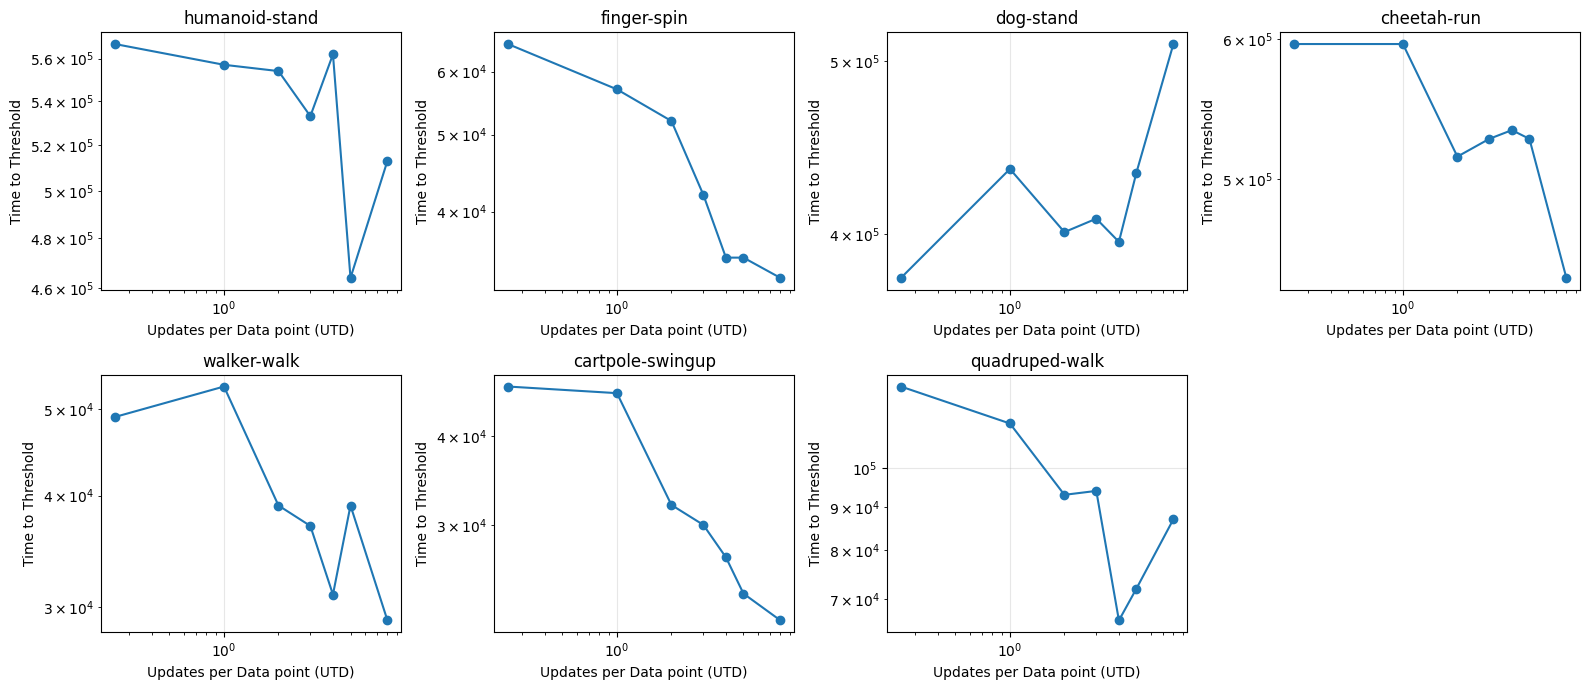

In [40]:
# Plot time to threshold for each environment using closest hyperparameters to fit
envs = list(set(proposed_values['Environment']))
n_envs = len(envs)
n_cols = 4
n_rows = (n_envs + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 7))
axes = axes.flatten()

# Store per-env data in a dictionary
env_data_dict = {}

for i, env in enumerate(envs):
    # Get all data points for this environment
    env_data = []
    for utd, e, lr, bs in zip(proposed_values['UTD'],
                             proposed_values['Environment'], 
                             proposed_values['Learning Rate'],
                             proposed_bs_values['Batch Size']):
        if utd == '0.50' or utd == '16.00':
            continue
        if e == env:
            # Find closest learning rate and batch size in the data for this environment
            env_df = df[df['env_name'] == env]
            lr_diffs = np.abs(env_df['learning_rate'] - float(lr))
            bs_diffs = np.abs(env_df['batch_size'] - float(bs))
            utd_diffs = np.abs(env_df['utd'] - float(utd))
            closest_match = (lr_diffs + bs_diffs + utd_diffs).idxmin()
            
            # print(df.loc[closest_match, 'crossings'])
            # print(closest_match)
            # print(df.loc[closest_match, 'utd'], df.loc[closest_match, 'learning_rate'], df.loc[closest_match, 'batch_size'], df.loc[closest_match, 'env_name'])
            env_data.append((float(utd), df.loc[closest_match, 'crossings'][-1]))
    
    # Store data for this environment
    env_data_dict[env] = env_data
    
    if len(env_data) > 0:
        # Unzip the data
        utds, times = zip(*env_data)
        
        # Plot with log scales
        # print(utds)
        # print(times)
        axes[i].plot(utds, times, 'o-')
        axes[i].set_xlabel('Updates per Data point (UTD)')
        axes[i].set_ylabel('Time to Threshold')
        axes[i].set_title(f'{env}')
        axes[i].set_xscale('log')
        axes[i].set_yscale('log')
        axes[i].grid(True, alpha=0.3)

# Remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



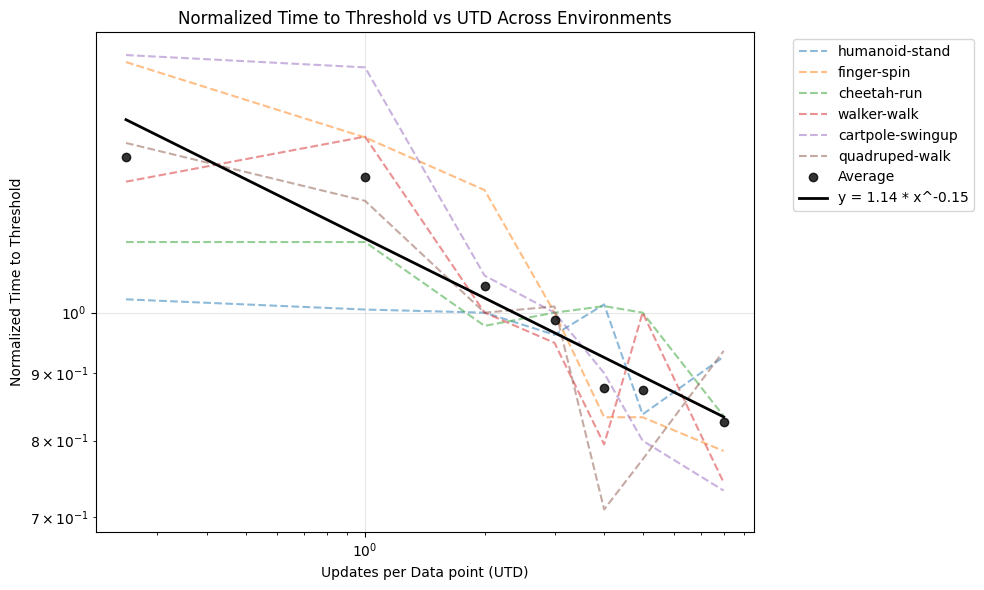

In [41]:
# Plot all environments on one plot
plt.figure(figsize=(10, 6))

# Filter out dog stand environment
filtered_data = {env: data for env, data in env_data_dict.items() if env != 'dog-stand'}

median_times = np.array([np.median(list(zip(*data))[1]) for data in filtered_data.values() if len(data) > 0])
median_median = np.median(median_times)
scaling = 1 / median_times

# Store the normalized data for each environment
normalized_times_all = []
for i, (env, data) in enumerate(filtered_data.items()):
    utds, times = zip(*data)
    normalized_times = np.array(times) * scaling[i]
    normalized_times_all.append(normalized_times)
    plt.plot(utds, normalized_times, '--', label=env, alpha=0.5)

# Calculate and plot the average across all environments    
normalized_times_all = np.array(normalized_times_all)

plt.plot(utds, np.mean(normalized_times_all, axis=0), 'ko', linewidth=3, label='Average', alpha=0.8)

# Fit a line to log-transformed data
log_utds = np.log(utds)
log_mean_times = np.log(np.mean(normalized_times_all, axis=0))
slope, intercept = np.polyfit(log_utds, log_mean_times, 1)

# Plot the fit line
fit_x = np.array([min(utds), max(utds)])
fit_y = np.exp(slope * np.log(fit_x) + intercept)
plt.plot(fit_x, fit_y, 'k-', linewidth=2, 
         label=f'y = {np.exp(intercept):.2f} * x^{slope:.2f}')


plt.xlabel('Updates per Data point (UTD)')
plt.ylabel('Normalized Time to Threshold')
plt.title('Normalized Time to Threshold vs UTD Across Environments')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



## Asymptotic data efficiency fit

In [42]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from ast import arg
import matplotlib.pyplot as plt
from tqdm import tqdm

import scipy

def fit(xs, y, optim_f, init_grid, top_k=500, n_proc=8, tol=None, disp=False, maxiter=None):
        _, _, brute_xs, brute_ys = scipy.optimize.brute(optim_f, init_grid, args=(xs, y), full_output=True, finish=None, Ns=1, workers=-1)

        brute_xs = brute_xs.reshape(brute_xs.shape[0], -1)
        brute_ys = brute_ys.reshape(-1)

        top_idxs = np.argsort(brute_ys)[:top_k]
        top_xs = brute_xs[:, top_idxs]
        # top_ys = brute_ys[top_idxs]
        preds = []
        for i in tqdm(range(top_xs.shape[1])):
            options = {'disp': disp}
            if maxiter: options['maxiter'] = maxiter
            pred = scipy.optimize.minimize(optim_f, top_xs[:, i], args=(xs, y), method='L-BFGS-B', tol=tol, options=options).x
            loss = optim_f(pred, xs, y)
            # print(pred, loss)
            preds.append((pred, loss))
        return sorted(preds, key=lambda x: x[1])[0][0]

def power_law_with_const_min(args, *params):
    x,y = params
    a,b,c = args
    # return ((power_law_with_const(x,a,b,c) - y) ** 2).mean()
    with np.errstate(invalid='ignore', divide='ignore'):
        return ((np.log(power_law_with_const(x,a,b,c) / y)) ** 2).mean()

def power_law_with_const(x, a, b, c): return c * (1 + (x/b)**(-a))


 32%|███▏      | 40/125 [00:00<00:01, 51.79it/s]/home/oleh/miniconda3/envs/rlgpu/lib/python3.7/site-packages/scipy/optimize/_numdiff.py:557: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0
100%|██████████| 125/125 [00:01<00:00, 92.64it/s] 



Environment Asymptotic Times
-----------------------------------
  Environment    |    Asymptote   
-----------------------------------
 humanoid-stand  | 1.3e+05
  finger-spin    | 9.6e+03
  cheetah-run    | 1.2e+05
  walker-walk    | 8.9e+03
cartpole-swingup | 6.8e+03
 quadruped-walk  | 2.1e+04
-----------------------------------


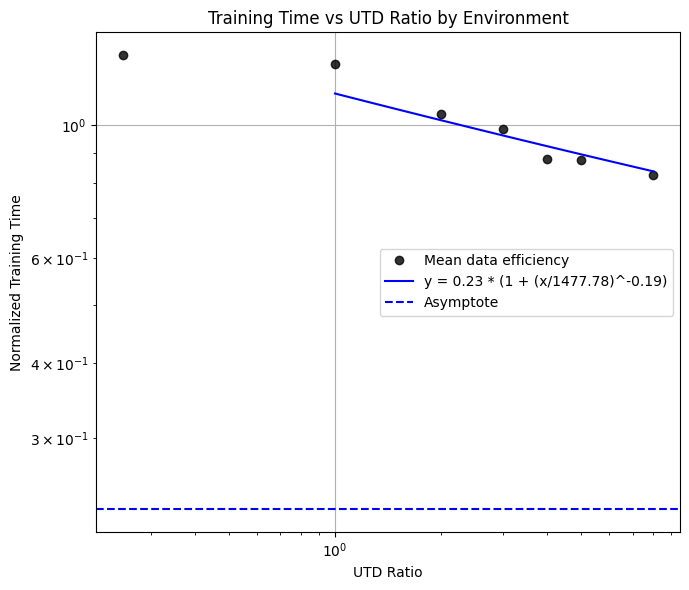

In [43]:
# Pareto fit 

plt.figure(figsize=(7, 6))

plt.plot(utds, np.mean(normalized_times_all, axis=0), 'ko', linewidth=3, label='Mean data efficiency', alpha=0.8)

# Pareto fit 

# Fit power law with constant to the mean data
mean_times = np.mean(normalized_times_all, axis=0)
fitted_params = fit(utds, mean_times, power_law_with_const_min,
                   [slice(-2, 2, 0.8), slice(0, 1, 0.2), slice(-2, 2, 0.8)], maxiter=100)

a, b, c = fitted_params

# Generate smooth curve for plotting
x_smooth = np.logspace(0, np.log10(8), 100) 
y_fitted = power_law_with_const(x_smooth, a, b, c)

# Plot the data and fit
plt.title('Normalized training time')
# plt.scatter(utds, mean_times, color='blue', label='Mean across envs')
plt.plot(x_smooth, y_fitted, 'b-', 
         label=f'y = {c:.2f} * (1 + (x/{b:.2f})^-{a:.2f})')

# Plot the asymptote
plt.axhline(y=c, color='b', linestyle='--', label=f'Asymptote')

# Print asymptote (c parameter) for each environment separately
# Create a table header
print("\nEnvironment Asymptotic Times")
print("-" * 35)
print(f"{'Environment':^16} | {'Asymptote':^15}")
print("-" * 35)

# Print each environment's asymptote in table format
for env_idx in range(normalized_times_all.shape[0]):
    asymp = c * median_times[env_idx]
    print(f"{list(filtered_data.keys())[env_idx]:^16} | {asymp:^.1e}")
print("-" * 35)


plt.xscale('log')
plt.yscale('log')
plt.grid(True)
plt.xlabel('UTD Ratio') 
plt.ylabel('Normalized Training Time')
plt.title('Training Time vs UTD Ratio by Environment')
plt.legend()
plt.tight_layout()
plt.show()

